#### Libraries:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import cvxpy as cp
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="scs")


#### Data from Gerber paper:
columns = ["SPX Index", "RTY Index", "MXEA Index", "MXEF Index", "LBUSTRUU Index", "LF98TRUU Index", "FNERTR Index", "XAU Curncy", "SPGSCI Index"]

In [ ]:
path = 'gerber_return_data.xlsx'
data_gerber = pd.read_excel(path)
data_gerber["Date"] = pd.to_datetime(data_gerber["Date"]) # ensure Date column is a datetime object

# The Gerber Statistic

#### **Paper:**
**The Gerber Statistic**: A Robust Co-Movement Measure for Portfolio Optimization

By Sander Gerber, Harry M. Markowitz, Philip A. Ernst,
Yinsen Miao, Babak Javid, and Paul Sargen


#### **Goal:** To have a more robust correlation/co-movement measure (a more robust covariance matrix)

**Problems with sample (historical) covariance:**
- Sample covariance matrices are sensitive to outliers
    - Problematic for portfolio optimization
- Sample covariance matrices misinterpret noise as correlation
    - Small returns (that may be noise) contribute to the calculation, potentially resulting in overestimation

**How does the Gerber statistic get around this?**
- It ignores returns below a threshold
    - i.e. these are dropped from the calculation entirely
- It limits the impact of extreme values 
    - Returns above the threshold contribute equal amounts
- According to the paper, it is a generalization of Kendall's Tau


## Defining the Gerber statistic
- $k = 1, \dots, K$ securities; $t = 1, \dots, T$ time periods.  
- $r_{tk}$ = return of security $k$ at time $t$.  

For each pair $(i, j)$ of assets and each time $t$, define the joint observation $m_{ij}(t)$:

$$
m_{ij}(t) =
\begin{cases}
+1 & \text{if } r_{ti} \geq +H_i \text{ and } r_{tj} \geq +H_j \\
+1 & \text{if } r_{ti} \leq -H_i \text{ and } r_{tj} \leq -H_j \\
-1 & \text{if } r_{ti} \geq +H_i \text{ and } r_{tj} \leq -H_j \\
-1 & \text{if } r_{ti} \leq -H_i \text{ and } r_{tj} \geq +H_j \\
0 & \text{otherwise}
\end{cases}
$$

Thresholds are defined as:

$$
H_k = c s_k
$$

where $c$ is a constant (commonly $0.5$, sometimes $0.7$ or $0.9$) and $s_k$ is the sample standard deviation of security $k$. Essentially, you end up with a vector of $m_{ij}(t)$ values for each asset pair $(i, j)$.

**Interpretation of $m_{ij}(t)$:**
- $+1$: both series exceed thresholds in the **same direction** (concordant pair)  
- $-1$: both series exceed thresholds in **opposite directions** (discordant pair)
- $0$: at least one series does not cross its threshold.

#### Initial Statistic
The co-movement statistic for a pair $(i,j)$ is:

$$
g_{ij} = \frac{\sum_{t=1}^{T} m_{ij}(t)}{\sum_{t=1}^{T} |m_{ij}(t)|}
$$

- Counts the **direction of threshold crossings** only, not their magnitude.  
- **Robust properties:**
  - Insensitive to extreme returns (ignores magnitude).  
  - Insensitive to noise (ignores small, sub-threshold returns).

#### Gerber Function:

In [3]:
def compute_thresholds(x, y, H1=None, H2=None, c=0.5):
    """
    Compute thresholds for two series.

    Parameters:
    -----------
    x, y : pd.Series
        Return series for two assets.
    H1, H2 : float, optional
        Thresholds. If None, computed as c * std.
    c : float, default=0.5
        Threshold multiplier.

    Returns:
    --------
    (H1, H2) : tuple of floats
        Thresholds for x and y.
    """
    if H1 is None:
        H1 = c * x.std()
    if H2 is None:
        H2 = c * y.std()
    return H1, H2


def gerber(x, y, c=0.5):

    """
    Compute the original (raw) Gerber statistic between two asset return series.

    Parameters
    ----------
    x : array-like (1D)
        Return series of asset i.
    y : array-like (1D)
        Return series of asset j.
    c : float, optional (default=0.5)
        Threshold multiplier. Thresholds Hx and Hy are set as:
            Hk = c * std(return_k)
        where std is the sample standard deviation of each series.

    Returns
    -------
    float
        Gerber statistic in the range [-1, 1], defined as:
            g_ij = (n_concordant - n_discordant) / (n_concordant + n_discordant)

        - A value close to +1 indicates strong concordant co-movement 
          (both assets move in the same direction when above thresholds).
        - A value close to -1 indicates strong discordant co-movement 
          (assets move in opposite directions when above thresholds).
        - A value near 0 indicates little or no meaningful co-movement 
          once noise is filtered out.

    Notes
    -----
    - This implementation corresponds to GERBERRAW in Flint & Polakow (2023).
    - For a positive semidefinite covariance estimator suitable for optimization, 
      see the modified form (Equation A-3 in Gerber et al. 2022), implemented 
      in `gerber_v2`.
    """

    # Compute thresholds
    Hx, Hy = compute_thresholds(x, y, None, None, c)
    
    # Simple implementation of m_ij(t), using a loop (just for illustration)
    # 
    # m = []
    # for xi, yi in zip(x, y):
    #     if xi >= Hx and yi >= Hy:
    #         m.append(1)
    #     elif xi <= -Hx and yi <= -Hy:
    #         m.append(1)
    #     elif xi >= Hx and yi <= -Hy:
    #         m.append(-1)
    #     elif xi <= -Hx and yi >= Hy:
    #         m.append(-1)
    #     else:
    #         m.append(0)
    # return m

    # Compute m_ij(t) (vectorized using numpy)
    conditions = [
        (x >= Hx) & (y >= Hy),       # both exceed +threshold
        (x <= -Hx) & (y <= -Hy),     # both below -threshold
        (x >= Hx) & (y <= -Hy),      # x up, y down
        (x <= -Hx) & (y >= Hy)       # x down, y up
    ]
    choices = [1, 1, -1, -1]
    m = np.select(conditions, choices, default=0)

    numerator = m.sum()
    denominator = np.abs(m).sum()
    
    if denominator == 0:
        return 0  # no concordant/discordant pairs
    return numerator / denominator


##### Calculation Check:

In [4]:
# subset the time period
df_sub = data_gerber[
    (data_gerber["Date"] >= "2019-01-31") &
    (data_gerber["Date"] <= "2020-12-31")
]

# extract the two return series
x = df_sub["SPX Index"]
y = df_sub["XAU Curncy"]

# compute Gerber statistic
g_stat = gerber(x, y, c=0.5) 
print("Gerber statistic (SPX vs XAU, 2019-01-31 to 2020-12-31):", g_stat)

Gerber statistic (SPX vs XAU, 2019-01-31 to 2020-12-31): 0.6


This compares concordant vs. discordant threshold-crossing events.

- **Concordant pair**: both securities cross thresholds in the **same direction**.  
- **Discordant pair**: both cross thresholds in **opposite directions**.  

Let $n_{ij}^c =$ number of concordant pairs, and $n_{ij}^d =$ number of discordant pairs:

$$
g_{ij} = \frac{n_{ij}^c - n_{ij}^d}{n_{ij}^c + n_{ij}^d} \tag{A-1}
$$

> **Note:** If all thresholds $H_k = 0$, Equation (A-1) reduces to **Kendall’s Tau**.

**Nine-Region Representation**
- Each security’s return is classified as:  
  - **U** (Up): above upper threshold.  
  - **N** (Neutral): between thresholds.  
  - **D** (Down): below lower threshold.  
- Joint return pairs fall into **9 regions** (UU, UN, UD, etc.).  
- Let $n_{ij}^{pq}$ = number of observations with asset $i$ in region $p$ and asset $j$ in region $q$.

With this, Equation (A-1) can be expressed as:

$$
g_{ij} = \frac{n_{ij}^{UU} + n_{ij}^{DD} - n_{ij}^{UD} - n_{ij}^{DU}}
{n_{ij}^{UU} + n_{ij}^{DD} + n_{ij}^{UD} + n_{ij}^{DU}} \tag{A-2}
$$

To illustrate this we look at a scatter plot with thresholds:

0.021275857521014085 0.024264241665232333


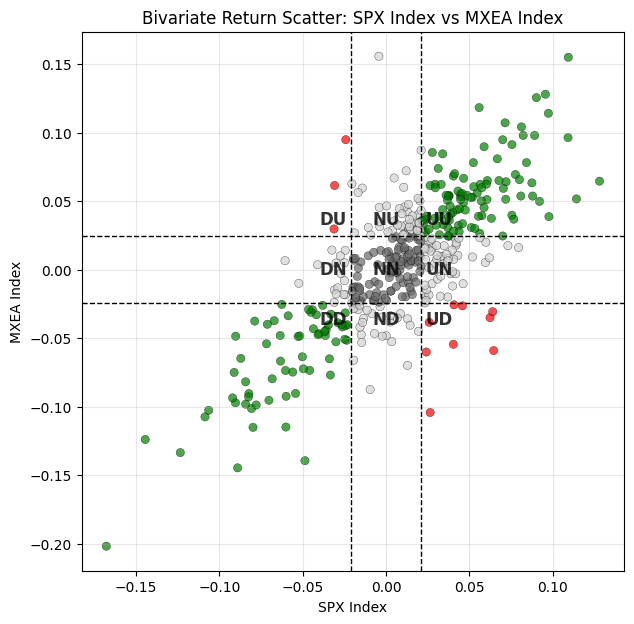

In [5]:
def plot_bivariate_scatter(df, col1, col2, H1=None, H2=None, c=0.5):
    x = df[col1].dropna()
    y = df[col2].dropna()
    data = pd.concat([x, y], axis=1).dropna()
    x, y = data[col1], data[col2]

    # Compute thresholds
    H1, H2 = compute_thresholds(x, y, H1, H2, c)
    print(H1, H2)

    # Classification of points into zones
    def classify_point(xi, yi):
        if xi >= H1 and yi >= H2:
            return "UU"
        elif xi <= -H1 and yi <= -H2:
            return "DD"
        elif xi >= H1 and yi <= -H2:
            return "UD"
        elif xi <= -H1 and yi >= H2:
            return "DU"
        elif abs(xi) < H1 and abs(yi) < H2:
            return "NN"
        elif abs(xi) < H1 and yi >= H2:
            return "NU"
        elif abs(xi) < H1 and yi <= -H2:
            return "ND"
        elif xi >= H1 and abs(yi) < H2:
            return "UN"
        elif xi <= -H1 and abs(yi) < H2:
            return "DN"
        else:
            return "Other"

    regions = [classify_point(xi, yi) for xi, yi in zip(x, y)]

    # Color map
    color_map = {
        "UU": "green", "DD": "green",       # concordant
        "UD": "red", "DU": "red",           # discordant
        "NN": "dimgray",                    # middle
        "NU": "lightgray", "ND": "lightgray", "UN": "lightgray", "DN": "lightgray",
        "Other": "lightgray"
    }
    colors = [color_map[r] for r in regions]

    # Plot points
    plt.figure(figsize=(7, 7))
    plt.scatter(x, y, c=colors, alpha=0.7, edgecolor="k", linewidth=0.3)

    # Threshold lines
    plt.axvline(x=H1, color="black", linestyle="--", lw=1)
    plt.axvline(x=-H1, color="black", linestyle="--", lw=1)
    plt.axhline(y=H2, color="black", linestyle="--", lw=1)
    plt.axhline(y=-H2, color="black", linestyle="--", lw=1)

    # Define label positions (centers of cells)
    label_positions = {
        "UU": ( H1*1.5,  H2*1.5),
        "DU": (-H1*1.5,  H2*1.5),
        "UN": ( H1*1.5,   0),
        "DN": (-H1*1.5,   0),
        "UD": ( H1*1.5, -H2*1.5),
        "DD": (-H1*1.5, -H2*1.5),
        "NU": (0,  H2*1.5),
        "ND": (0, -H2*1.5),
        "NN": (0, 0)
    }

    for label, (lx, ly) in label_positions.items():
        plt.text(lx, ly, label, fontsize=12, weight="bold",
                 ha="center", va="center", color="black", alpha=0.8)

    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.title(f"Bivariate Return Scatter: {col1} vs {col2}")
    plt.grid(True, alpha=0.3)
    plt.show()

# Scatter plot with quadrants
plot_bivariate_scatter(data_gerber, "SPX Index", "MXEA Index")

## **Positive Semidefinite Matrices**

A symmetric matrix $\Sigma \in \mathbb{R}^{n \times n}$ is called **positive semidefinite (PSD)** if it satisfies the following condition:
$$
x^\top \Sigma x \geq 0 \quad \forall x \in \mathbb{R}^n
$$
This means that the quadratic form generated by $\Sigma$ is always non-negative, regardless of the choice of vector $x$.


### Distinction from Positive Definite
- **Positive definite (PD):** $x^\top \Sigma x > 0$ for all non-zero $x$.  
- **Positive semidefinite (PSD):** $x^\top \Sigma x \geq 0$ for all $x$ (zero is allowed).


### Covariance Matrices
The variance of a portfolio with weights $w$ is defined as:

$$
\sigma_p^2 = w^\top \Sigma w
$$

where $\Sigma$ is the covariance matrix of asset returns. 
- Variance must always be non-negative
- This only happens if $\Sigma$ is positive semidefinite (PSD)
- i.e. when:

$$
w^\top \Sigma w \geq 0 \quad \forall w
$$

---

## Back to Gerber
According to the authors, the covariance matrix $G$ was often not PSD. To overcome this, they introduce a new statistic.

The **Gerber Statistic (final form)** is defined as:

$$
g_{ij} = \frac{n_{ij}^{UU} + n_{ij}^{DD} - n_{ij}^{UD} - n_{ij}^{DU}}
{T - n_{ij}^{NN}} \tag{A-3}
$$

where $T$ is the total number of observations and $n_{ij}^{NN}$ counts times both securities are neutral.

See proof of PSD: https://arxiv.org/pdf/2305.05663

### Final Gerber Function:

In [6]:
def gerber_v2(x, y, c=0.5):
    """
    Compute the Gerber statistic (positive semidefinite version) 
    between two asset return series.

    Parameters
    ----------
    x : array-like (1D)
        Return series of asset i.
    y : array-like (1D)
        Return series of asset j.
    c : float, optional (default=0.5)
        Threshold multiplier. Thresholds Hx and Hy are set as:
            Hk = c * std(return_k)
        where std is the sample standard deviation of each series.

    Returns
    -------
    float
        Gerber statistic in the range [-1, 1], defined as:

            g_ij = (n_concordant - n_discordant) / (T - n_NN)

        where:
        - n_concordant = number of times both exceed thresholds in the same direction (UU, DD)
        - n_discordant = number of times both exceed thresholds in opposite directions (UD, DU)
        - T = total number of observations
        - n_NN = number of times both series fall inside their thresholds (neutral zone)

        - Values near +1 indicate strong concordant co-movement.
        - Values near -1 indicate strong discordant co-movement.
        - Values near 0 indicate weak or no meaningful co-movement.

    Notes
    -----
    - This corresponds to Equation (A-3) in Gerber et al. (2022), 
      the recommended form for use in mean–variance optimization.
    - By construction, this form is to yield 
      positive semidefinite covariance matrices across assets.
    """

    # Compute thresholds
    Hx, Hy = compute_thresholds(x, y, None, None, c)
    
    # Compute m_ij(t) (vectorized using numpy)
    conditions = [
        (x >= Hx) & (y >= Hy),       # both exceed +threshold
        (x <= -Hx) & (y <= -Hy),     # both below -threshold
        (x >= Hx) & (y <= -Hy),      # x up, y down
        (x <= -Hx) & (y >= Hy)       # x down, y up
    ]
    choices = [1, 1, -1, -1]
    m = np.select(conditions, choices, default=0)

    numerator = m.sum() # The numerator is that same as before
    denominator = len(m) - np.sum((np.abs(x) < Hx) & (np.abs(y) < Hy))

    
    if denominator == 0:
        return 0  # no concordant/discordant pairs
    return numerator / denominator

##### Another calculation check:

In [7]:
# subset the time period
df_sub = data_gerber[
    (data_gerber["Date"] >= "2019-01-31") &
    (data_gerber["Date"] <= "2020-12-31")
]

# extract the two return series
x = df_sub["SPX Index"]
y = df_sub["XAU Curncy"]

# compute Gerber statistic
g_stat_v2 = gerber_v2(x, y, c=0.5) 
print("Gerber statistic v2 (SPX vs XAU, 2019-01-31 to 2020-12-31):", g_stat_v2)

Gerber statistic v2 (SPX vs XAU, 2019-01-31 to 2020-12-31): 0.2857142857142857


## Empirical Study (Gerber et al)

### Dataset
- Monthly Returns of Nine 'diversified' assets, January 1988 – October 2022 (the paper uses only goes up to 2020):
1. S&P 500 (SPX, US large-cap equities)
2. Russell 2000 (RTY, US small-cap equities)
3. MSCI EAFE (MXEA, developed markets ex-US/Canada)
4. MSCI Emerging Markets (MXEF)
5. Bloomberg Barclays US Aggregate Bond (LBUSTRUU)
6. Bloomberg Barclays US Corporate High Yield Bond (LF98TRUU)
7. FTSE NAREIT Equity REITs (FNERTR)
8. Gold (XAU)
9. S&P GSCI Commodity Index (SPGSCI)

Preview of data:

In [8]:
data_gerber.head()

,Date,SPX Index,RTY Index,MXEA Index,MXEF Index,LBUSTRUU Index,LF98TRUU Index,FNERTR Index,XAU Curncy,SPGSCI Index
0,1988-01-29,0.042051,0.043619,0.017852,0.094200,0.035152,0.033446,0.054803,-0.053914,0.013996
1,1988-02-29,0.046607,0.090136,0.066688,0.002376,0.011870,0.032363,0.038240,-0.069541,-0.017044
2,1988-03-31,-0.030875,0.046758,0.061456,0.099927,-0.009385,-0.010396,0.004972,0.072275,0.045241
3,1988-04-29,0.011066,0.022741,0.014509,0.046668,-0.005396,0.007635,0.006952,-0.017398,0.022255
4,1988-05-31,0.008635,-0.026876,-0.032037,0.026530,-0.006722,0.001505,-0.014752,0.014477,0.017028


#### Correlation Plots:
To explore the data and the GS, we look at correlation heat maps. The functions used are as follows:

In [9]:
def gerber_matrix(df, c=0.5, gerber_func=gerber):
    """
    Compute the Gerber correlation matrix for a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame of returns (numeric only, no Date column).
    c : float, optional
        Threshold multiplier.
    gerber_func : function, optional
        Function to compute Gerber correlation between two series.
        Defaults to gerber(), but can also use gerber_v2().

    Returns
    -------
    corr : pd.DataFrame
        Gerber correlation matrix.
    """
    cols = df.columns
    n = len(cols)
    corr = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)

    for i, col_i in enumerate(cols):
        for j, col_j in enumerate(cols):
            if i <= j:  # fill upper triangle incl diag
                gij = gerber_func(df[col_i], df[col_j], c)
                corr.loc[col_i, col_j] = gij
                corr.loc[col_j, col_i] = gij  # symmetry
    return corr



def plot_correlation_heatmap(df, method="pearson", cmap="RdBu", annot=False, gerber_func=None, c=0.5):
    """
    Plot a correlation heatmap for all columns in a DataFrame, excluding 'Date'.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with a 'Date' column and numeric columns.
    method : str, optional
        Correlation method: 'pearson', 'spearman', 'kendall', or 'gerber'.
    cmap : str, optional
        Colormap for the heatmap.
    annot : bool, optional
        If True, annotates the heatmap with correlation values.
    gerber_func : function, optional
        A function that takes a DataFrame (numeric cols only) and returns
        a Gerber correlation matrix (pd.DataFrame).
    c : float, optional (default=0.5)
        Threshold multiplier for Gerber correlation.
    """
    # Drop Date column if present
    if "Date" in df.columns:
        data = df.drop(columns=["Date"])
    else:
        data = df.copy()

    # Choose correlation method
    if method.lower() in ["pearson", "spearman", "kendall"]:
        corr = data.corr(method=method.lower())
    elif method.lower() == "gerber":
        if gerber_func is None:
            raise ValueError("You must pass a gerber_func when using method='gerber'")
        corr = gerber_func(data, c=c)  # pass threshold multiplier along
    else:
        raise ValueError(f"Unknown method: {method}. Use 'pearson', 'spearman', 'kendall', or 'gerber'.")

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=annot, cmap=cmap, center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

    # Title: only include c if using Gerber
    if method.lower() == "gerber":
        plt.title(f"Correlation Heatmap ({method.capitalize()}, c={c})", fontsize=14, pad=15)
    else:
        plt.title(f"Correlation Heatmap ({method.capitalize()})", fontsize=14, pad=15)

    plt.show()

#### Comparison of Pearson and Gerber Heat maps for different thresholds:

##### C = 0.9:

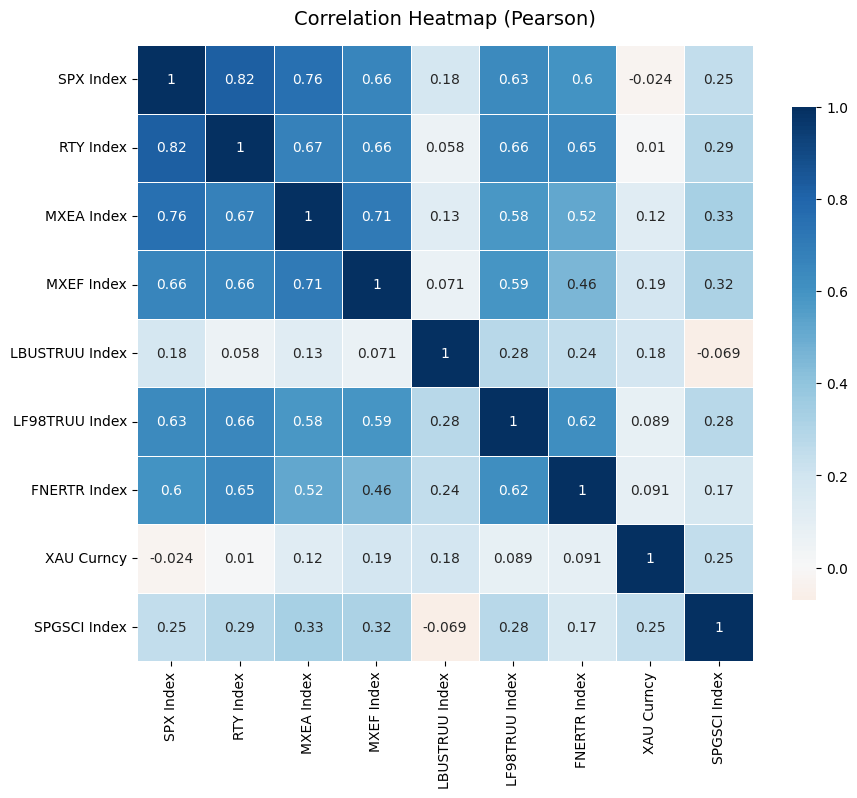

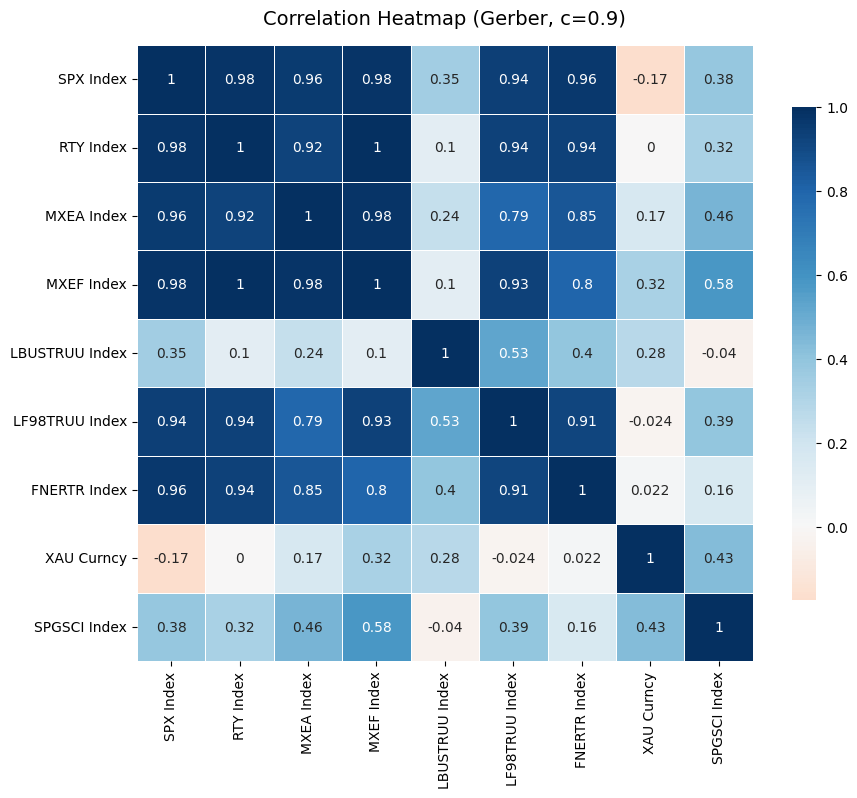

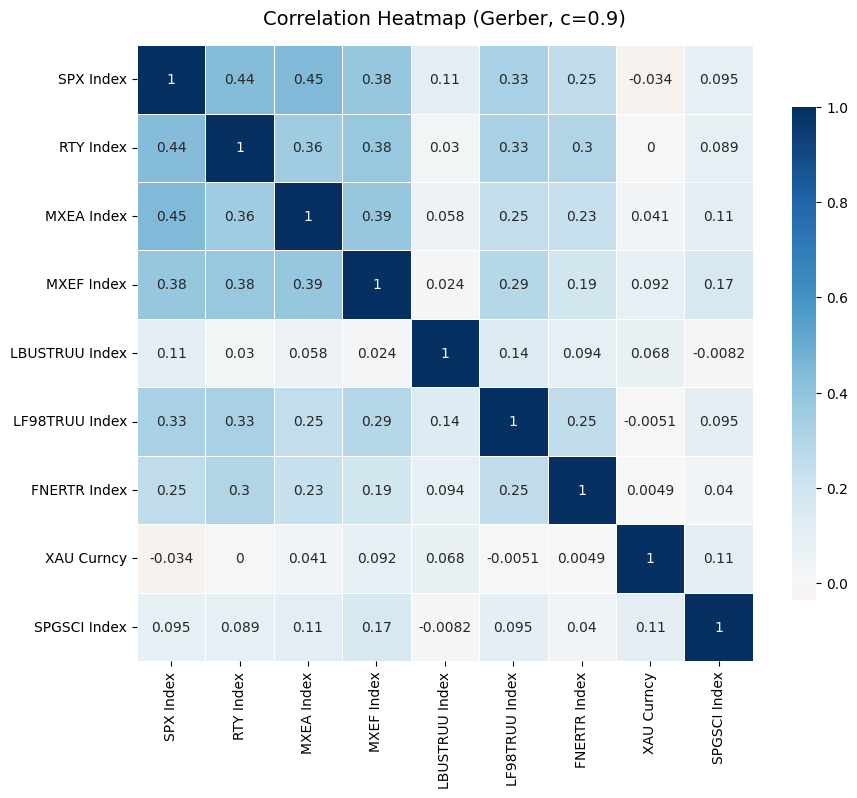

In [10]:
plot_correlation_heatmap(data_gerber, method="pearson", annot=True) # pearson
plot_correlation_heatmap(data_gerber, method="gerber", annot=True, gerber_func=gerber_matrix, c=0.9) # gerber old
plot_correlation_heatmap(
    data_gerber,
    method="gerber",
    annot=True,
    gerber_func=lambda df, c: gerber_matrix(df, c=c, gerber_func=gerber_v2),
    c=0.9
) # gerber final


##### C = 0.7:

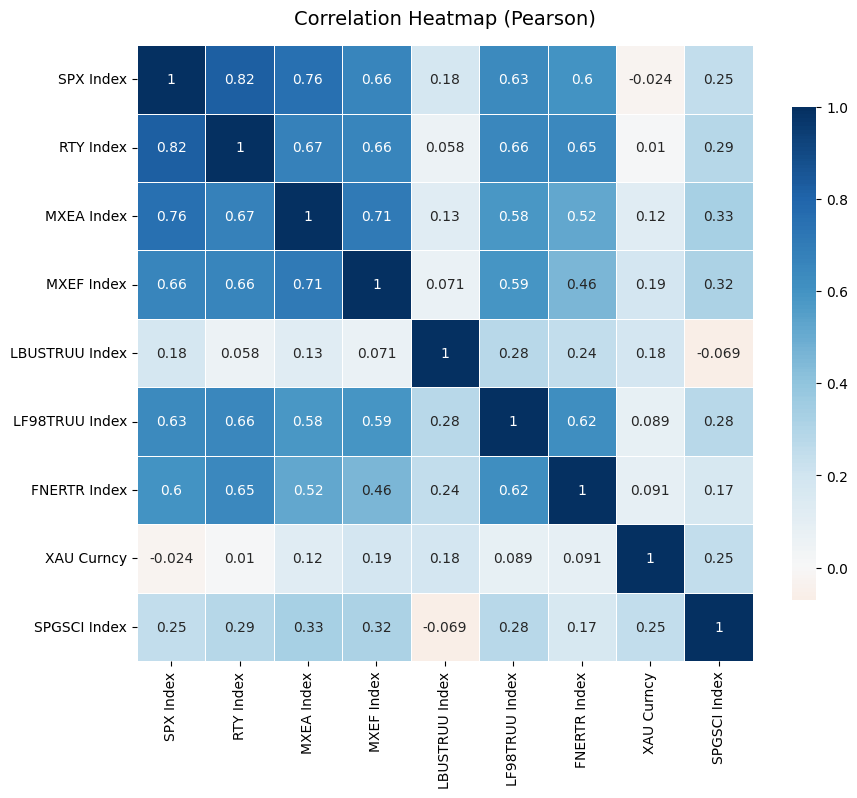

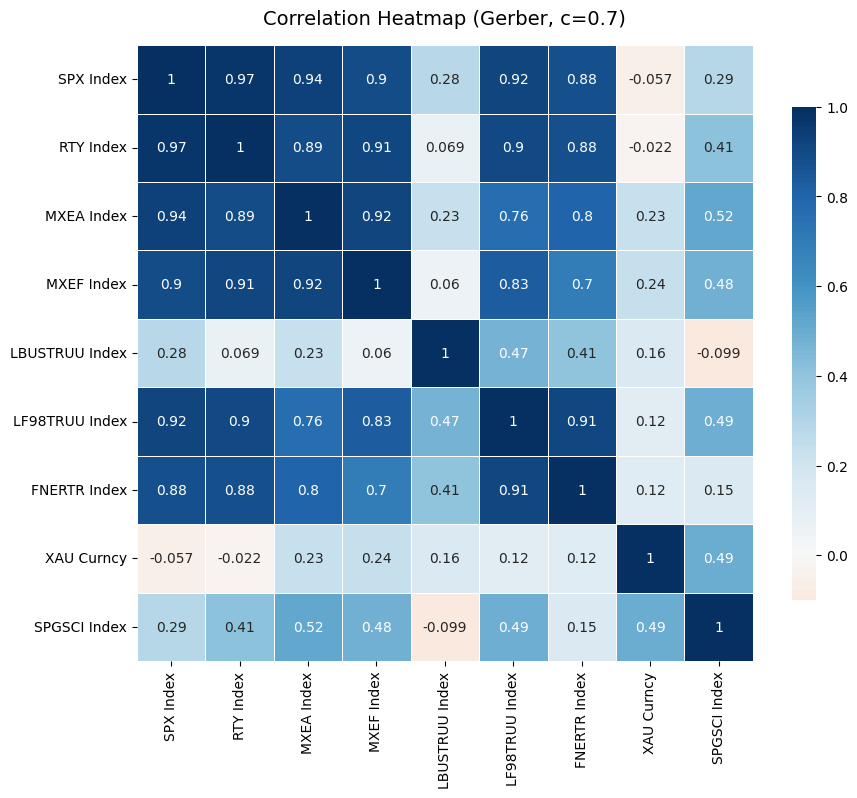

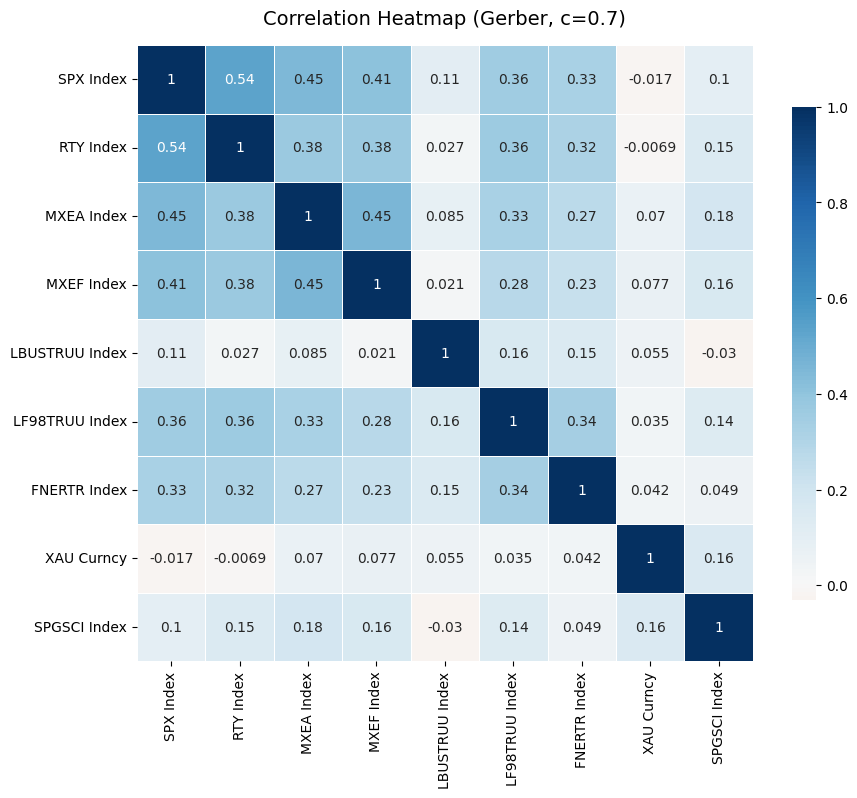

In [11]:
plot_correlation_heatmap(data_gerber, method="pearson", annot=True)
plot_correlation_heatmap(data_gerber, method="gerber", annot=True, gerber_func=gerber_matrix, c=0.7)
plot_correlation_heatmap(
    data_gerber,
    method="gerber",
    annot=True,
    gerber_func=lambda df, c: gerber_matrix(df, c=c, gerber_func=gerber_v2),
    c=0.7
)

##### C = 0.5:

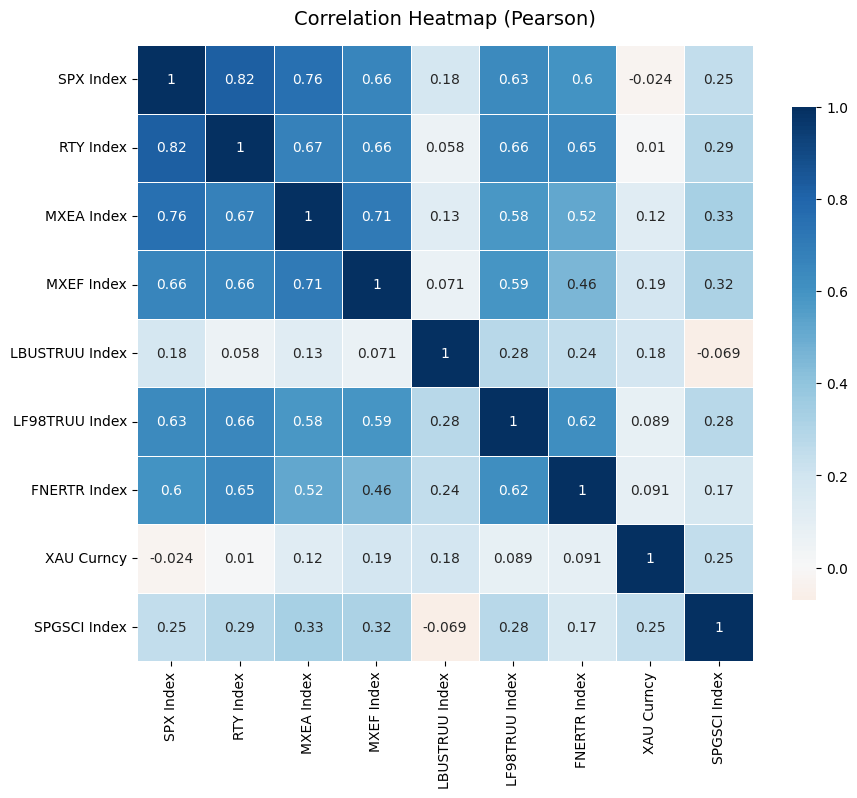

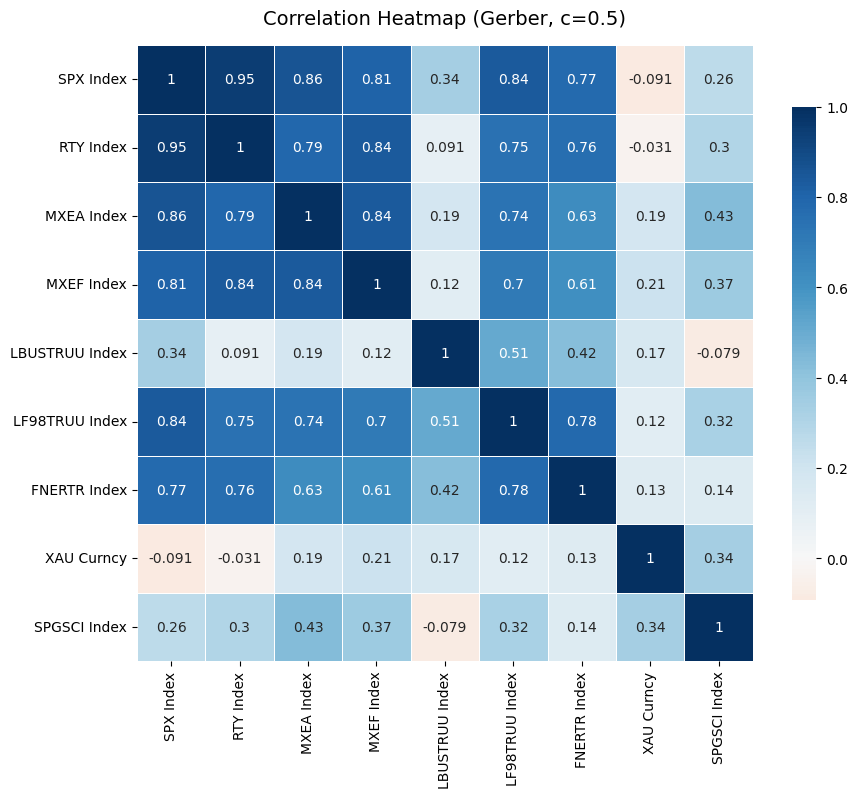

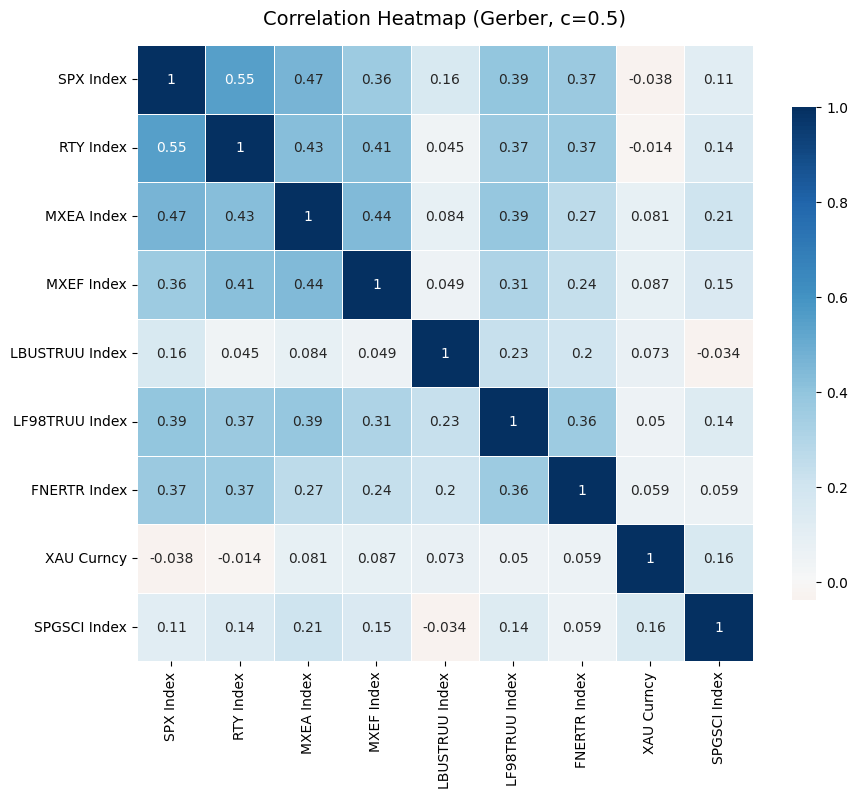

In [12]:
plot_correlation_heatmap(data_gerber, method="pearson", annot=True)
plot_correlation_heatmap(data_gerber, method="gerber", annot=True, gerber_func=gerber_matrix, c=0.5)
plot_correlation_heatmap(
    data_gerber,
    method="gerber",
    annot=True,
    gerber_func=lambda df, c: gerber_matrix(df, c=c, gerber_func=gerber_v2),
    c=0.5
)


##### C = 0.1:

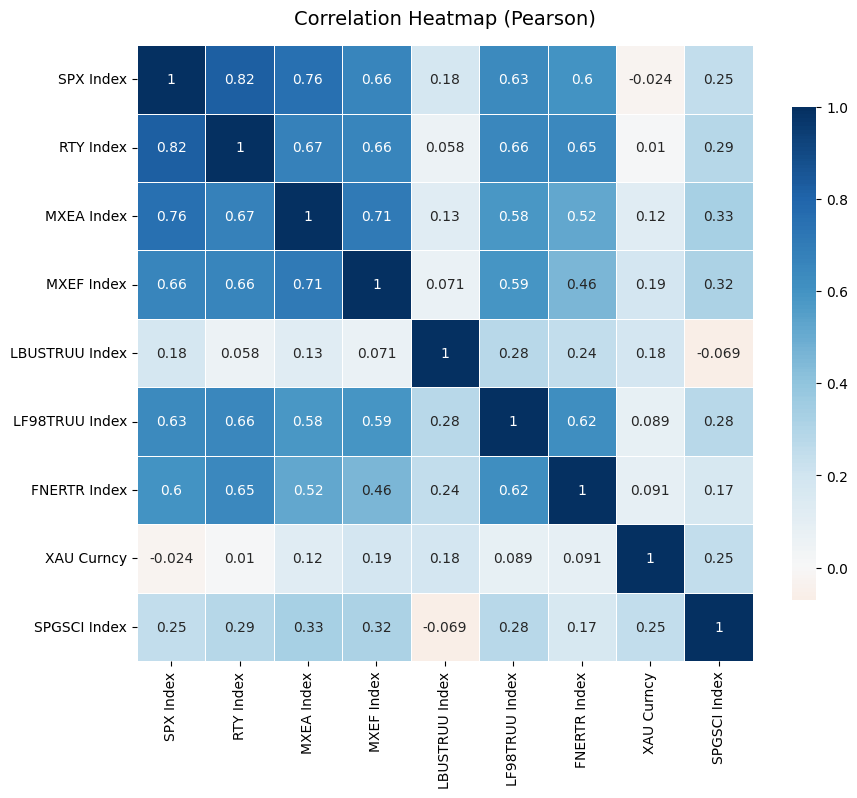

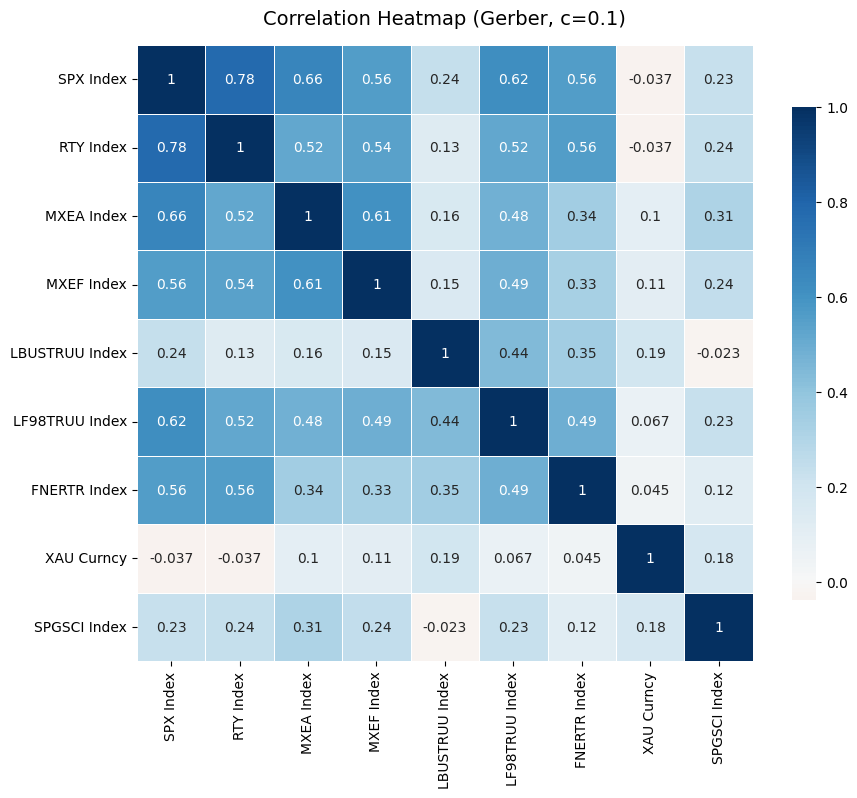

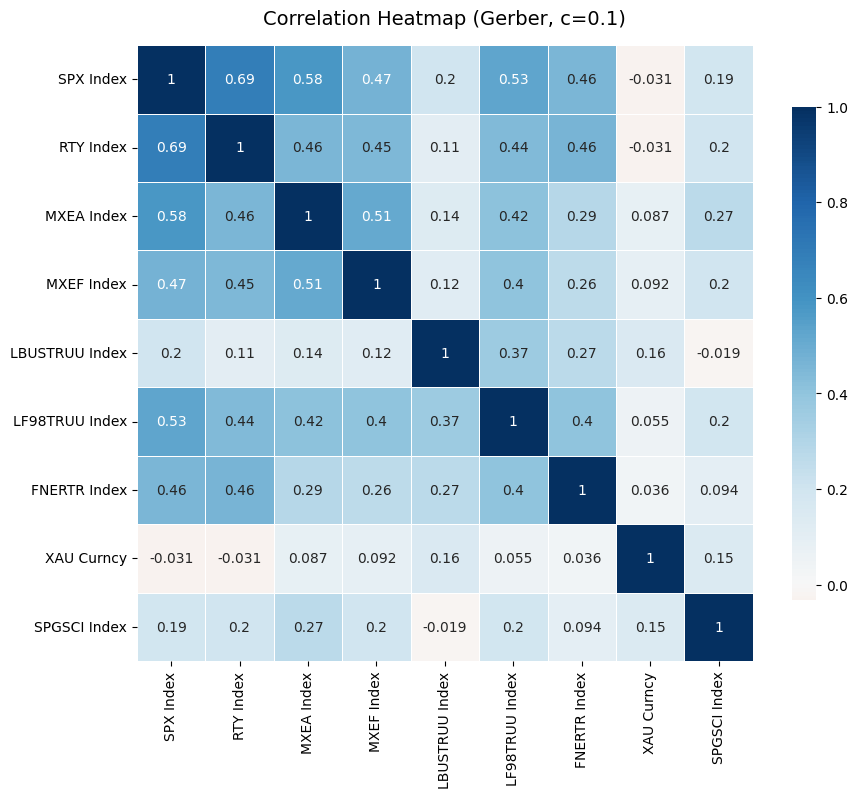

In [13]:
plot_correlation_heatmap(data_gerber, method="pearson", annot=True)
plot_correlation_heatmap(data_gerber, method="gerber", annot=True, gerber_func=gerber_matrix, c=0.1)
plot_correlation_heatmap(
    data_gerber,
    method="gerber",
    annot=True,
    gerber_func=lambda df, c: gerber_matrix(df, c=c, gerber_func=gerber_v2),
    c=0.1
)


#### The plots differ quite a bit based on the calculation as well as threshold. We investigate this further by looking at the Gerber values as a function of the threshold c:

In [14]:
def plot_gerber_vs_c(df, assets, c_values=None, standardize=False):
    """
    Plot Gerber statistic (both forms) as a function of threshold c
    for given asset pairs, with a horizontal line showing Pearson correlation.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame of returns with columns as assets.
    assets : list of tuple
        List of (asset1, asset2) pairs, e.g. [("SPX Index", "XAU Curncy")]
    c_values : array-like, optional
        Range of threshold multipliers. Default: np.linspace(0, 3.6, 60)
    standardize : bool, optional
        If True, standardize each series (zero mean, unit variance) before computing.
    """
    if c_values is None:
        c_values = np.linspace(0, 3.6, 60)

    for asset1, asset2 in assets:
        x = df[asset1].dropna()
        y = df[asset2].dropna()
        # Align series
        data = pd.concat([x, y], axis=1).dropna()
        x, y = data[asset1], data[asset2]

        if standardize:
            x = (x - x.mean()) / x.std(ddof=1)
            y = (y - y.mean()) / y.std(ddof=1)

        # Pearson correlation
        pearson_corr = x.corr(y, method="pearson")

        g1_vals, g2_vals = [], []
        for c in c_values:
            g1_vals.append(gerber(x, y, c=c))
            g2_vals.append(gerber_v2(x, y, c=c))

        plt.figure(figsize=(8, 5))
        plt.plot(c_values, g1_vals, label="Gerber (Raw, A-1 style)", marker="o")
        plt.plot(c_values, g2_vals, label="Gerber (Final, A-3)", marker="s")
        plt.axhline(0, color="black", lw=1, linestyle="--")
        plt.axhline(pearson_corr, color="grey", lw=1.5, linestyle=":", 
                    label=f"Pearson corr = {pearson_corr:.2f}")
        plt.xlabel("Threshold multiplier c")
        plt.ylabel("Gerber statistic")
        title_suffix = " (standardized)" if standardize else ""
        plt.title(f"Gerber statistic vs c: {asset1} vs {asset2}{title_suffix}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()



Pairs for easy use:

In [15]:
# pairs = [
#     # SPX
#     ("SPX Index", "RTY Index"),
#     ("SPX Index", "MXEA Index"),
#     ("SPX Index", "MXEF Index"),
#     ("SPX Index", "LBUSTRUU Index"),
#     ("SPX Index", "LF98TRUU Index"),
#     ("SPX Index", "FNERTR Index"),
#     ("SPX Index", "XAU Curncy"),
#     ("SPX Index", "SPGSCI Index"),

#     # RTY
#     ("RTY Index", "SPX Index"),
#     ("RTY Index", "MXEA Index"),
#     ("RTY Index", "MXEF Index"),
#     ("RTY Index", "LBUSTRUU Index"),
#     ("RTY Index", "LF98TRUU Index"),
#     ("RTY Index", "FNERTR Index"),
#     ("RTY Index", "XAU Curncy"),
#     ("RTY Index", "SPGSCI Index"),

#     # MXEA
#     ("MXEA Index", "SPX Index"),
#     ("MXEA Index", "RTY Index"),
#     ("MXEA Index", "MXEF Index"),
#     ("MXEA Index", "LBUSTRUU Index"),
#     ("MXEA Index", "LF98TRUU Index"),
#     ("MXEA Index", "FNERTR Index"),
#     ("MXEA Index", "XAU Curncy"),
#     ("MXEA Index", "SPGSCI Index"),

#     # MXEF
#     ("MXEF Index", "SPX Index"),
#     ("MXEF Index", "RTY Index"),
#     ("MXEF Index", "MXEA Index"),
#     ("MXEF Index", "LBUSTRUU Index"),
#     ("MXEF Index", "LF98TRUU Index"),
#     ("MXEF Index", "FNERTR Index"),
#     ("MXEF Index", "XAU Curncy"),
#     ("MXEF Index", "SPGSCI Index"),

#     # LBUSTRUU
#     ("LBUSTRUU Index", "SPX Index"),
#     ("LBUSTRUU Index", "RTY Index"),
#     ("LBUSTRUU Index", "MXEA Index"),
#     ("LBUSTRUU Index", "MXEF Index"),
#     ("LBUSTRUU Index", "LF98TRUU Index"),
#     ("LBUSTRUU Index", "FNERTR Index"),
#     ("LBUSTRUU Index", "XAU Curncy"),
#     ("LBUSTRUU Index", "SPGSCI Index"),

#     # LF98TRUU
#     ("LF98TRUU Index", "SPX Index"),
#     ("LF98TRUU Index", "RTY Index"),
#     ("LF98TRUU Index", "MXEA Index"),
#     ("LF98TRUU Index", "MXEF Index"),
#     ("LF98TRUU Index", "LBUSTRUU Index"),
#     ("LF98TRUU Index", "FNERTR Index"),
#     ("LF98TRUU Index", "XAU Curncy"),
#     ("LF98TRUU Index", "SPGSCI Index"),

#     # FNERTR
#     ("FNERTR Index", "SPX Index"),
#     ("FNERTR Index", "RTY Index"),
#     ("FNERTR Index", "MXEA Index"),
#     ("FNERTR Index", "MXEF Index"),
#     ("FNERTR Index", "LBUSTRUU Index"),
#     ("FNERTR Index", "LF98TRUU Index"),
#     ("FNERTR Index", "XAU Curncy"),
#     ("FNERTR Index", "SPGSCI Index"),

#     # XAU
#     ("XAU Curncy", "SPX Index"),
#     ("XAU Curncy", "RTY Index"),
#     ("XAU Curncy", "MXEA Index"),
#     ("XAU Curncy", "MXEF Index"),
#     ("XAU Curncy", "LBUSTRUU Index"),
#     ("XAU Curncy", "LF98TRUU Index"),
#     ("XAU Curncy", "FNERTR Index"),
#     ("XAU Curncy", "SPGSCI Index"),

#     # SPGSCI
#     ("SPGSCI Index", "SPX Index"),
#     ("SPGSCI Index", "RTY Index"),
#     ("SPGSCI Index", "MXEA Index"),
#     ("SPGSCI Index", "MXEF Index"),
#     ("SPGSCI Index", "LBUSTRUU Index"),
#     ("SPGSCI Index", "LF98TRUU Index"),
#     ("SPGSCI Index", "FNERTR Index"),
#     ("SPGSCI Index", "XAU Curncy"),
# ]


#### Gerber as a function of c

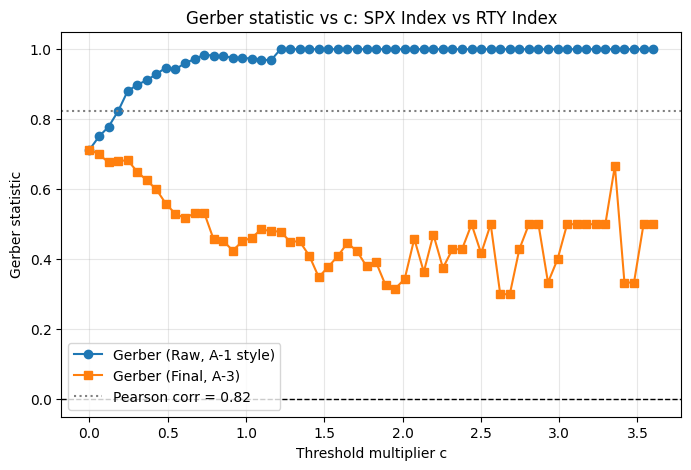

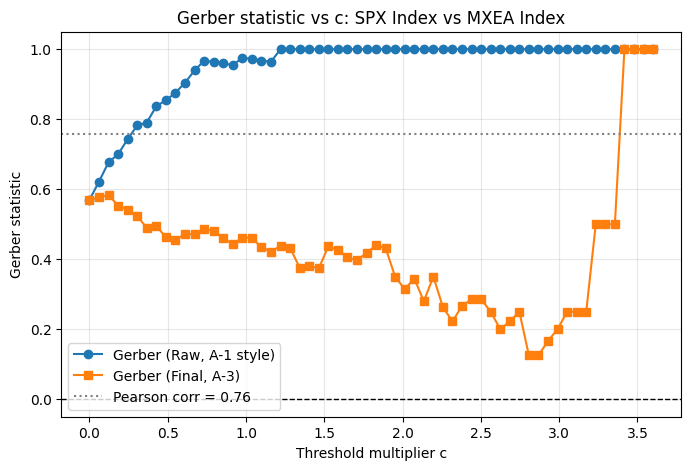

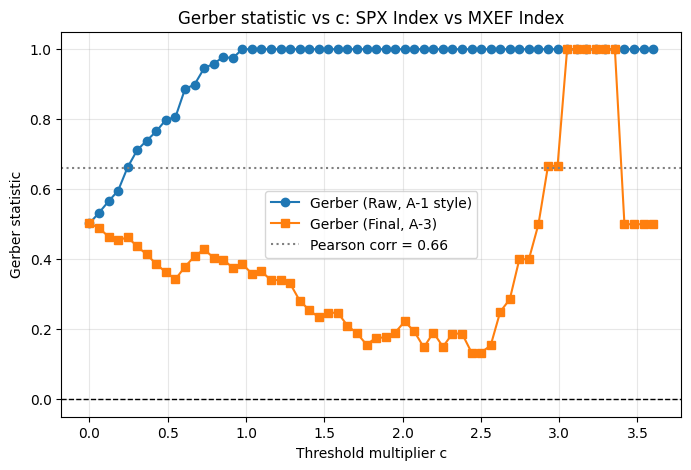

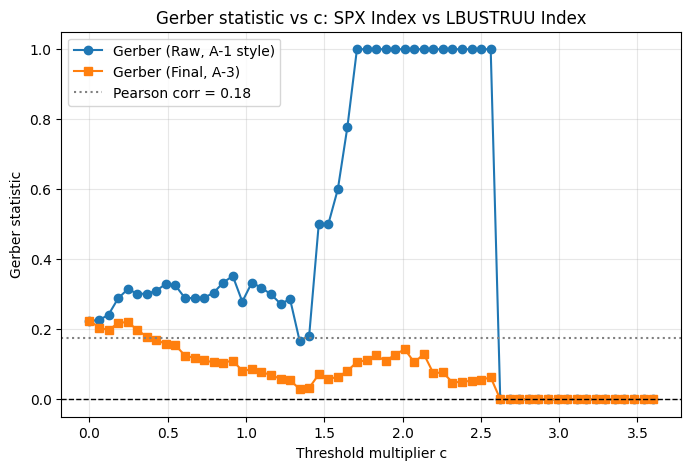

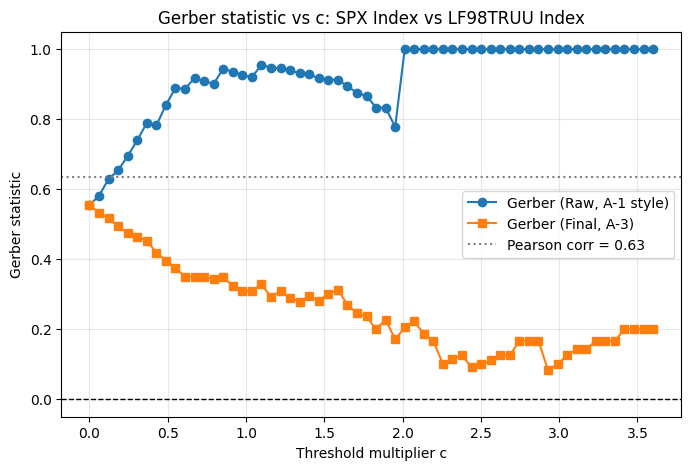

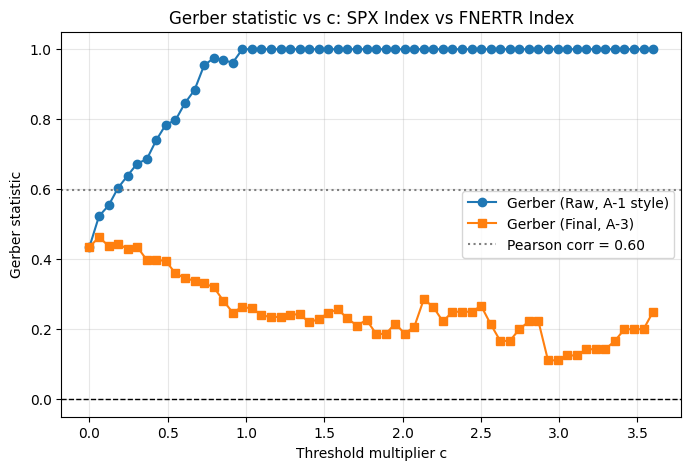

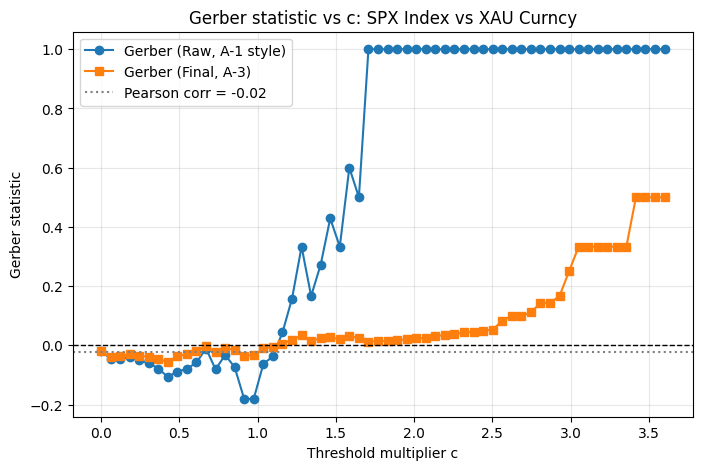

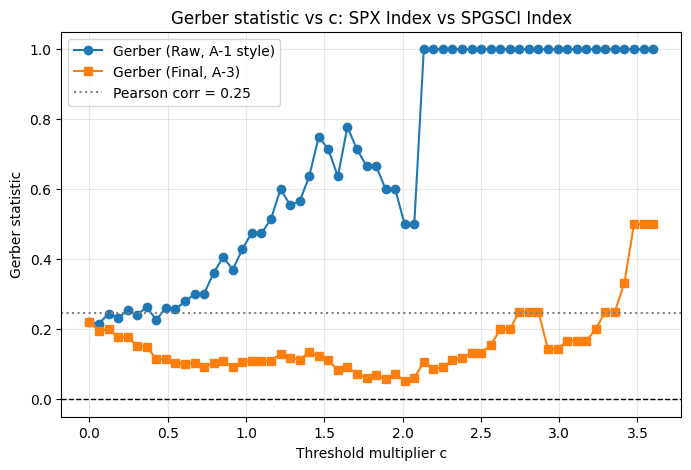

In [16]:
plot_gerber_vs_c(data_gerber, [
    ("SPX Index", "RTY Index"),
    ("SPX Index", "MXEA Index"),
    ("SPX Index", "MXEF Index"),
    ("SPX Index", "LBUSTRUU Index"),
    ("SPX Index", "LF98TRUU Index"),
    ("SPX Index", "FNERTR Index"),
    ("SPX Index", "XAU Curncy"),
    ("SPX Index", "SPGSCI Index")
])

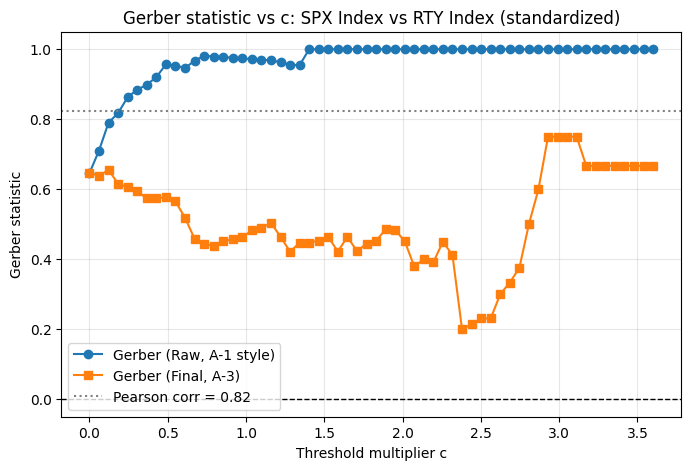

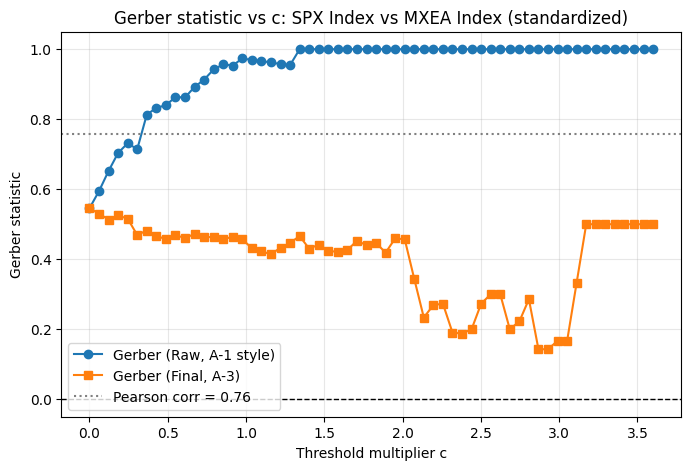

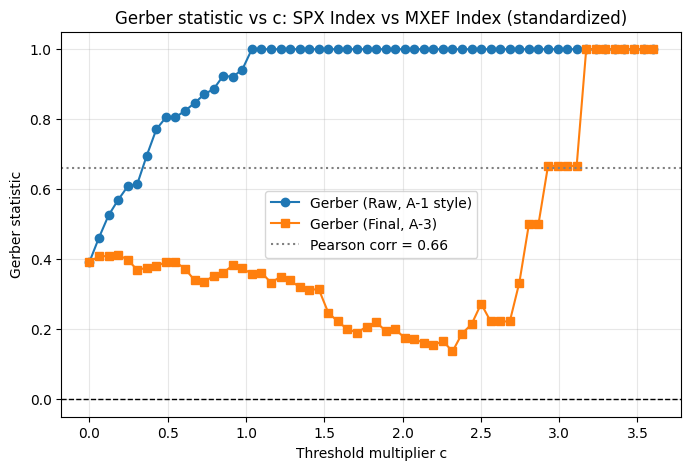

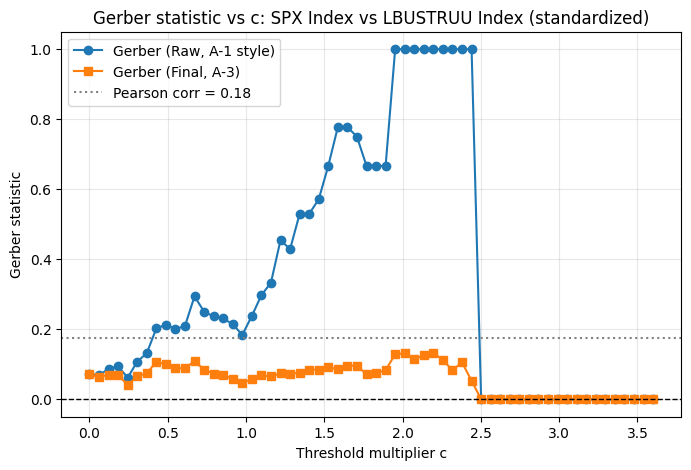

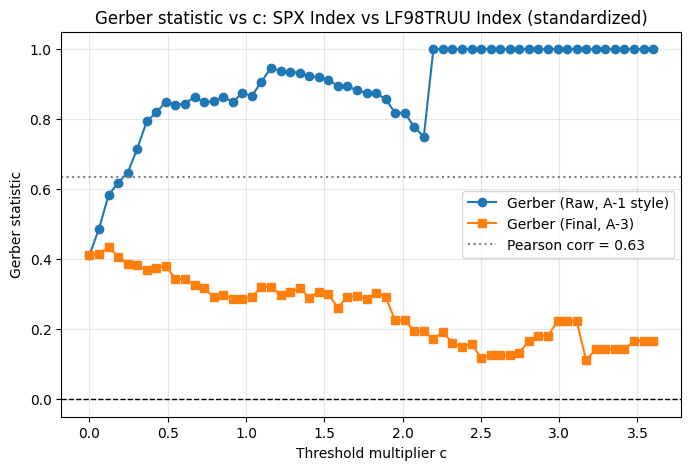

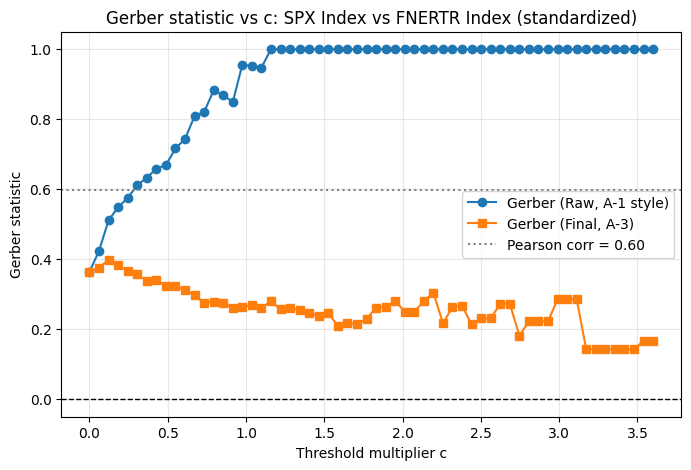

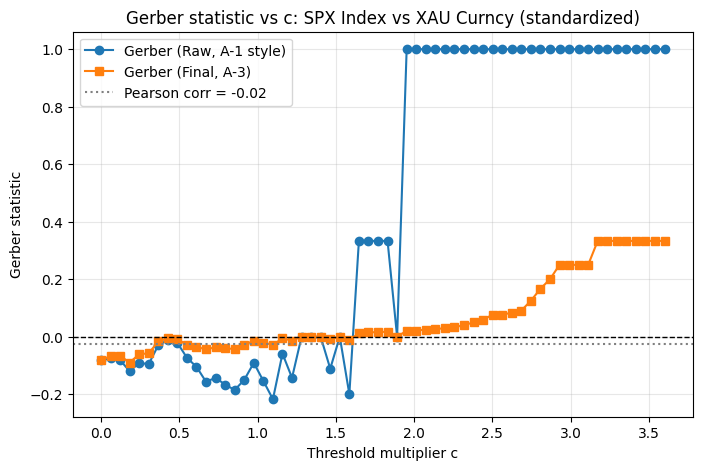

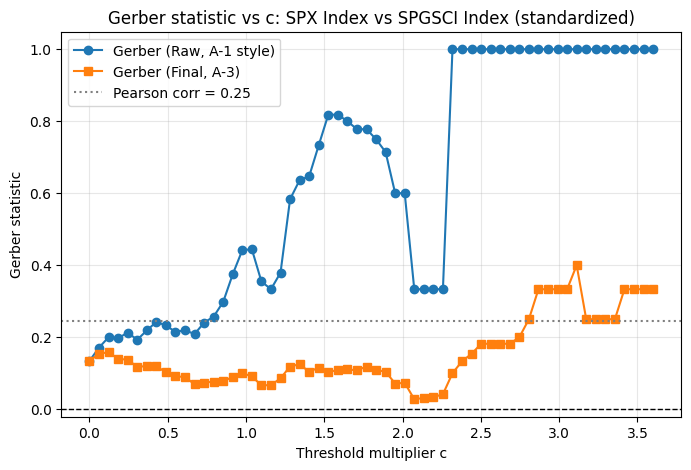

In [17]:
plot_gerber_vs_c(data_gerber, [
    ("SPX Index", "RTY Index"),
    ("SPX Index", "MXEA Index"),
    ("SPX Index", "MXEF Index"),
    ("SPX Index", "LBUSTRUU Index"),
    ("SPX Index", "LF98TRUU Index"),
    ("SPX Index", "FNERTR Index"),
    ("SPX Index", "XAU Curncy"),
    ("SPX Index", "SPGSCI Index")
], None, True)

The odd behaviour illustrated in these plots is a good segway to the next paper

## **Paper:**
**Deconstructing the Gerber Statistic** by Emlyn Flint & Daniel Polakow

### Research Purpose
- Explore GS behaviour across thresholds and under different market conditions (normal, fat-tailed, skewed).  
- Build intuition around GS’s mechanics and assess its efficacy as a dependence measure.  


### **Questions to be answered**:
1. Effect of Threshold?
2. How do the differnt GS measures differ?
3. Behaviour of GS for different $\rho$ values?
4. Estimation error for realistic sample sizes?
5. How does GS change as more realistic market conditions (fat tails, left skew) are considered?
6. Shrinkage?

#### Gerber Statistics (they look at three)
Original:
$$
\operatorname{GERBER}_{R A W}=\frac{\left(n^{U U}+n^{D D}\right)-\left(n^{U D}+n^{D U}\right)}{\left(n^{U U}+n^{D D}\right)+\left(n^{U D}+n^{D U}\right)}
$$

Alternative (new):
$$
G E R B E R_{A L T}=\frac{\left(n^{U U}+n^{D D}\right)-\left(n^{U D}+n^{D U}\right)}{\sqrt{n^{(A)} n^{(B)}}}
$$

Where
$$
\begin{aligned}
&\begin{aligned}
& n^{(A)}=\left(n^{U U}+n^{U N}+n^{U D}\right)+\left(n^{D U}+n^{D N}+n^{D D}\right) \\
& n^{(B)}=\left(n^{U U}+n^{N U}+n^{D U}\right)+\left(n^{U D}+n^{N D}+n^{D D}\right)
\end{aligned}
\end{aligned}
$$

Final:
$$
G E R B E R_{F I N}=\frac{\left(n^{U U}+n^{D D}\right)-\left(n^{U D}+n^{D U}\right)}{T-n^{N N}}
$$

#### Simulation Procedure
1. **Specify distribution**: Choose type of joint return distribution and its fixed parameters.  
2. **Simulate returns**: Generate $T$ return pairs, then **standardise** them to zero mean and unit variance.  
3. **Calculate GS**: Compute GS profiles across thresholds $H_i \in [0,3]$ for each GS variant.  
4. **Repeat & average**: Repeat simulations 500 times. Record average GS values across runs to produce smooth, unbiased profiles.  
5. **Vary distributions**: Repeat process for different distributions and parameter combinations.

#### Distributions Considered
- **Bivariate normal** (with varying correlation $\rho \in [-1,1]$).  
- **Bivariate Student’s t** (df = 4, $\rho = 0.63$).  
- **Regime-switching model** of two normals:  
  - **Down regime**: $\mu = \{-0.1,-0.2\}$, $\sigma = \{0.2,0.4\}$, $\rho = 0.3$, probability $=0.22$
  - **Up regime**: $\mu = \{0.15,0.3\}$, $\sigma = \{0.075,0.15\}$, $\rho = 0.8$, probability $=0.78$
#### Estimation Details
- Baseline sample size: $T = 20,000$ simulated returns.  
- For sensitivity analysis (Fig. 5): smaller samples $T = \{12,24,36,48,60\}$.  
- **Standardisation**: Returns are standardized before GS estimation to:  
  - Eliminate effects of differing means.  
  - Ensure thresholds are directly comparable across assets.  
  - Express thresholds $H_i$ in standard deviation units.

#### Results: **See Slide Show**

---

## **Mean-Variance Optimization**
### **Set-Up**
You have $N$ assets with random returns $r = (r_1, r_2, \dots, r_N)^\top$.

Expected returns:
$$
\mu = \mathbb{E}[r] = (\mu_1, \mu_2, \dots, \mu_N)^\top
$$

Covariance matrix:
$$
\Sigma = \mathrm{Cov}(r)
$$

Portfolio weights:
$$
w = (w_1, w_2, \dots, w_N)^\top, \quad \sum_{i=1}^N w_i = 1
$$

Expected portfolio return:
$$
\mu_p = w^\top \mu
$$

Portfolio variance:
$$
\sigma_p^2 = w^\top \Sigma w
$$

### **Optimization Problem**
Minimize variance for a target return

$$
\begin{aligned}
\min_w \quad & w^\top \Sigma w \\
\text{s.t.} \quad & w^\top \mu \ge \mu^\ast \\
& \mathbf{1}^\top w = 1
\end{aligned}
$$

where $\mu^\ast$ is the target return, and $\mathbf{1}$ is a vector of ones. You can further constrain the $\omega$ vector to ensure long only portfolios.

### **The Dual Problem**

Fix a target variance level $\sigma_\ast^2$. The “dual” efficient-frontier formulation is:

$$
\begin{aligned}
\max_w \quad & w^\top \mu \\
\text{s.t.}\quad & w^\top \Sigma w \le \sigma_\ast^2, \\
& \mathbf{1}^\top w = 1 .
\end{aligned}
$$

- This produces the same efficient frontier as the variance-minimization problem with target return $\mu^\ast$.
- For any efficient portfolio, there exists a risk level $\sigma_\ast^2$ and a return level $\mu^\ast$ such that both formulations yield the **same** $w$.



## Historical Performance of Optimized Portfolios (as per Gerber et al)
### Purpose
Evaluate the performance of the GS for portfolio construction relative to two benchmark covariance estimators:
- **HC (Historical Covariance)**: sample covariance from Pearson correlations.
- **Ledoit–Wolf Shrinkage Estimator (2004)**: shrinks the sample covariance toward a structured target.

#### Competing Methods
- **HC (Historical Covariance):**
	- Based on Pearson product-moment correlation.
	- Sensitive to outliers and noise.
- **Ledoit–Wolf Shrinkage (SM):**
	- Convex combination of sample covariance and structured target.
	- Shrinkage constant controls strength of shrinkage.
- **Gerber Statistic (GS):**
	- Uses counts of concordant vs. discordant pairs (threshold-based).
	- Does not rely on sample covariance.
	- Provides a natural extension of Kendall’s Tau.
	- Flexible framework: can extend beyond returns to include rule-based concordance (e.g., incorporating volume, volatility).

#### Optimization and Backtesting Procedure
- Framework: **Mean–Variance Optimization (Markowitz, 1952, 1959)**.  
- Transaction cost: 10 bps ($0.1\%$ of traded volume).  
- Rolling-window procedure:
	- Start: January 1990.
	- Each month, use prior **24 months** of returns to estimate mean vector and covariance matrix.
	- Feed estimates into MVO to construct efficient portfolio.
	- Portfolios rebalanced monthly.
	- Process repeats by rolling forward one month.
- Evaluation period: January 1990 – December 2020.
- Advantages:  
	- Adaptive to market structural changes.  
	- Reduces data-mining bias by using out-of-sample rolling windows.

#### Results: See Slide Show

---

### Replication
Backtest code:
- portfolio optimizer - must take in data frame of returns and find optimal portfolio, arguments for constraints
- helper function to split the data so that a walk forward optimization can be done
    - optimize portfolio at each step
    - Calculate returns for t next month
    - rebalance portrolio
        - Shrink small weights to 0, re-normalize
    
- Performance metrics

#### Explanation:
- $K$ securities
- $T$ time periods
- $r_{tk}$ denotes the return of security $k$ at time $t$
- At each rebalance date $t \geq W$ (with lookback window $W$), we form an estimation set

$$
\mathcal{R}_t = \{ r_{sk} : s = t-W+1, \dots, t;\; k = 1, \dots, K \}.
$$

From $\mathcal{R}_t$, we estimate expected returns vector

$$
\hat{\mu}_t = \frac{1}{W} \sum_{s=t-W+1}^t r_s,
$$

and the covariance matrix $\hat{\Sigma}_t$, where $r_s = (r_{s1}, \dots, r_{sK})^\top$. Depending on the specification, $\hat{\Sigma}_t$ is the sample covariance, the Ledoit–Wolf shrinkage estimator, or the Gerber covariance with threshold $c$.

For a target volatility $\sigma^*$, portfolio weights are obtained by solving

$$
\max_{w_t} \; \hat{\mu}_t^\top w_t
\quad \text{s.t.} \quad 
w_t^\top \hat{\Sigma}_t w_t \le (\sigma^*)^2, \quad 
\mathbf{1}^\top w_t = 1, \quad
w_{\min} \leq w_{tk} \leq w_{\max}.
$$

The realized out-of-sample return is then

$$
R_{t+1} = w_t^\top r_{t+1}.
$$

This rolling procedure yields a time series $\{R_{t+1}\}$, from which performance metrics such as cumulative return, annualized volatility, and CAGR are computed.


In [18]:
def set_eps_wgt_to_zeros(in_array, eps=1e-4):
    """
    Set very small weights to zero, then renormalize to sum to 1.
    """
    out_array = np.array(in_array, dtype=float)
    out_array[np.abs(out_array) < eps] = 0.0
    out_array /= np.sum(out_array)
    return out_array

def ledoit_cov(returns_df: pd.DataFrame) -> np.ndarray:
    """
    Ledoit–Wolf constant-correlation shrinkage covariance (JPM-style).
    This function was taken from Gerber et al's GitHub and adapted.
    Input: DataFrame of returns (T x N). Output: covariance (N x N).
    """
    X = returns_df.values.astype(float)
    T, N = X.shape

    # Demean
    X = X - X.mean(axis=0, keepdims=True)

    # Sample covariance (population denom to match original LW derivation)
    sample = (X.T @ X) / T  # (N x N)

    # Prior: constant-correlation structure
    var = np.diag(sample)                         # (N,)
    # Build sqrt variances as 1xN row to create an NxN ratio by outer product
    sqrt_var_row = np.sqrt(var).reshape(1, -1)    # (1 x N)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = (1.0 / sqrt_var_row.T) @ sqrt_var_row  # (N x N), elements σ_j / σ_i
    ratio[~np.isfinite(ratio)] = 0.0  # safety for zero-var edge cases

    # Average off-diagonal correlation
    denom = sqrt_var_row.T @ sqrt_var_row         # (N x N)
    with np.errstate(divide='ignore', invalid='ignore'):
        corr = np.divide(sample, denom, out=np.zeros_like(sample), where=denom != 0)
    rBar = (corr.sum() - N) / (N * (N - 1))

    prior = rBar * denom                          # (N x N)
    np.fill_diagonal(prior, var)                  # keep variances from sample

    # phi-hat
    Y = X ** 2
    phiMat = (Y.T @ Y) / T - 2 * (X.T @ X) * sample / T + sample ** 2
    phi = phiMat.sum()

    # rho-hat
    term1 = (X ** 3).T @ X / T
    G = (X.T @ X) / T
    gdiag = np.diag(G).reshape(N, 1)
    term2 = gdiag @ np.ones((1, N)) * sample
    term3 = G * var.reshape(-1, 1)
    term4 = var.reshape(-1, 1) @ np.ones((1, N)) * sample
    thetaMat = term1 - term2 - term3 + term4
    np.fill_diagonal(thetaMat, 0.0)

    # elementwise multiply the NxN ratio with thetaMat
    rho = np.trace(phiMat) + rBar * np.sum(ratio * thetaMat)

    # gamma-hat
    gamma = np.linalg.norm(sample - prior, 'fro') ** 2

    # shrinkage intensity
    kappa = (phi - rho) / max(gamma, 1e-16)
    shrink = float(np.clip(kappa / T, 0.0, 1.0))

    cov = shrink * prior + (1.0 - shrink) * sample
    return cov

def optimal_portfolio_by_risk(returns_df: pd.DataFrame,
                              target_std: float,
                              min_weight: float = 0.0,
                              max_weight: float = 1.0,
                              eps: float = 1e-4,
                              init_w: np.ndarray | None = None,
                              maxiter: int = 2000,
                              ftol: float = 1e-9,
                              cov_type: str = "sample",  # "sample" or "gerber" (more later)
                              c: float = 0.5) -> np.ndarray:
    """
    Mean-variance optimizer with target volatility.
    The portfolio will have historical vol exactly equal to the target.

    Parameters
    ----------
    returns_df : pd.DataFrame
        Monthly returns (can include a 'Date' column).
    target_std : float
        Target annualized volatility.
    min_weight, max_weight : float
        Bounds on portfolio weights.
    eps : float
        Threshold to zero-out small weights.
    init_w : np.ndarray
        Optional warm start.
    maxiter, ftol : optimization parameters.
    cov_type : str
        Which covariance estimator to use ("sample", "gerber", ...).
    c : float
        Gerber threshold parameter (default 0.5).

    Returns
    -------
    np.ndarray
        Optimal portfolio weights.
    """
    # Drop Date if present
    returns_df = returns_df.drop(columns=["Date"], errors="ignore")

    n_assets = returns_df.shape[1]
    mu = returns_df.mean().values
    factor = 12
    mu_ann = mu * factor

    # --- covariance choice ---
    if cov_type == "sample":
        cov = returns_df.cov(ddof=1).values

    elif cov_type == "gerber":
        corr_gerber = gerber_matrix(returns_df, c=c, gerber_func=gerber_v2).values
        sigmas = returns_df.std(ddof=1).values
        cov = np.diag(sigmas) @ corr_gerber @ np.diag(sigmas)

    elif cov_type == "ledoit":
        cov = ledoit_cov(returns_df)
        # (optional) print or log shrinkage if you want to track it
        # print(f"Ledoit shrinkage: {shrinkage:.3f}")

    else:
        raise ValueError(f"Unknown cov_type '{cov_type}'")

    cov_ann = cov * factor

    # --- optimizer setup ---
    if init_w is None:
        init_w = np.ones(n_assets) / n_assets

    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: np.sqrt(w.T @ cov_ann @ w) - target_std}
    )
    bounds = tuple((min_weight, max_weight) for _ in range(n_assets))

    def neg_return(w): return -(mu_ann @ w)

    res = minimize(
        neg_return,
        init_w,
        method="SLSQP", # Sequential Least Squares Programming
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': maxiter, 'ftol': ftol, 'disp': False}
    )

    if not res.success:
        raise ValueError(f"Optimization failed: {res.message}")

    w = np.array(res.x, dtype=float)
    w[np.abs(w) < eps] = 0.0
    w /= w.sum()
    return w

def optimal_portfolio_by_risk_cvxpy(returns_df: pd.DataFrame,
                                    target_std: float,
                                    min_weight: float = 0.0,
                                    max_weight: float = 1.0,
                                    cov_type: str = "sample",
                                    c: float = 0.5) -> np.ndarray:
    """
    Mean-variance optimizer with target volatility using cvxpy (QP formulation).
    This portfolio will have historical vol less than or equal to the target.
    """

    # Drop Date if present
    returns_df = returns_df.drop(columns=["Date"], errors="ignore")

    n_assets = returns_df.shape[1]
    mu = returns_df.mean().values
    factor = 12
    mu_ann = mu * factor

    # --- covariance choice ---
    if cov_type == "sample":
        cov = returns_df.cov(ddof=1).values
    elif cov_type == "gerber":
        corr_gerber = gerber_matrix(returns_df, c=c, gerber_func=gerber_v2).values
        sigmas = returns_df.std(ddof=1).values
        cov = np.diag(sigmas) @ corr_gerber @ np.diag(sigmas)
    elif cov_type == "ledoit":
        cov = ledoit_cov(returns_df)
    else:
        raise ValueError(f"Unknown cov_type '{cov_type}'")

    cov_ann = cov * factor

    # --- cvxpy variables ---
    w = cp.Variable(n_assets)

    # objective: maximize expected return
    objective = cp.Maximize(mu_ann @ w)

    # constraints
    constraints = [
        cp.sum(w) == 1,  # budget constraint
        cp.quad_form(w, cov_ann) <= target_std**2,  # risk constraint
        w >= min_weight,
        w <= max_weight
    ]

    # define problem
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, verbose=False)

    if w.value is None:
        raise ValueError("Optimization failed")

    weights = np.array(w.value, dtype=float)
    weights[np.abs(weights) < 1e-8] = 0.0
    weights /= weights.sum()
    return weights

def rolling_mvo(returns_df: pd.DataFrame,
                target_stds: list,
                window: int = 24,
                min_weight: float = 0.0,
                max_weight: float = 1.0,
                eps: float = 1e-4,
                maxiter: int = 2000,
                ftol: float = 1e-9,
                cov_type: str = "sample",   # covariance estimator
                c: float = 0.5,             # Gerber threshold
                use_cvxpy: bool = False     # NEW: choose cvxpy optimizer
                ) -> dict:
    """
    Rolling MVO with per-month warm starts and graceful failure handling.

    Parameters
    ----------
    returns_df : pd.DataFrame
        Monthly returns with a 'Date' column or index.
    target_stds : list
        List of target annualized volatilities.
    window : int
        Lookback window in months (default 24).
    min_weight, max_weight : float
        Bounds on portfolio weights.
    eps : float
        Threshold for small weights.
    maxiter, ftol : optimization params for solver (SLSQP only).
    cov_type : str
        Which covariance estimator to use ("sample", "gerber", "ledoit").
    c : float
        Gerber threshold parameter.
    use_cvxpy : bool
        If True, use `optimal_portfolio_by_risk_cvxpy`, else use the SLSQP version.
    """

    # Ensure Date is index (flexible handling)
    if "Date" in returns_df.columns:
        returns_df = returns_df.set_index("Date")
    elif returns_df.index.name != "Date":
        raise ValueError("DataFrame must have a 'Date' column or index named 'Date'.")

    asset_columns = returns_df.columns
    n_assets = len(asset_columns)

    # store weights per vol level
    results = {f"Vol {int(tv*100)}%": [] for tv in target_stds}
    # remember last successful weights per vol level for warm starts
    last_w = {f"Vol {int(tv*100)}%": np.ones(n_assets)/n_assets for tv in target_stds}

    dates = []

    for t in range(window, len(returns_df)):
        window_data = returns_df.iloc[t-window:t]
        rebalance_date = returns_df.index[t]
        dates.append(rebalance_date)

        for tv in target_stds:
            key = f"Vol {int(tv*100)}%"
            init_w = last_w[key]

            try:
                if use_cvxpy:
                    # Use cvxpy-based optimizer (no warm start yet)
                    w = optimal_portfolio_by_risk_cvxpy(
                        window_data,
                        target_std=tv,
                        min_weight=min_weight,
                        max_weight=max_weight,
                        cov_type=cov_type,
                        c=c
                    )
                else:
                    # Use SLSQP-based optimizer (with warm start)
                    w = optimal_portfolio_by_risk(
                        window_data,
                        target_std=tv,
                        min_weight=min_weight,
                        max_weight=max_weight,
                        eps=eps,
                        init_w=init_w,
                        maxiter=maxiter,
                        ftol=ftol,
                        cov_type=cov_type,
                        c=c
                    )
                last_w[key] = w
            except Exception as e:
                # Fallback: use previous weights if optimization fails
                w = init_w
                # print(f"[{rebalance_date}] {key} failed: {e}. Using fallback weights.")

            results[key].append(w)

    # Convert to DataFrames
    weights_dfs = {
        k: pd.DataFrame(v, index=dates, columns=asset_columns)
        for k, v in results.items()
    }
    return weights_dfs

def portfolio_returns(returns_df: pd.DataFrame,
                      weights_df: pd.DataFrame) -> pd.Series:
    """
    Compute realized portfolio returns given rolling weights.

    Parameters
    ----------
    returns_df : pd.DataFrame
        Monthly returns with 'Date' column or index.
    weights_df : pd.DataFrame
        DataFrame of portfolio weights (rows = rebalance dates, cols = assets).

    Returns
    -------
    pd.Series
        Portfolio return series (aligned with rebalance dates +1).
    """

    # Ensure Date is index
    if "Date" in returns_df.columns:
        returns_df = returns_df.set_index("Date")

    # Align on common assets
    common_assets = returns_df.columns.intersection(weights_df.columns)
    returns_df = returns_df[common_assets]
    weights_df = weights_df[common_assets]

    # Shift weights forward by one month (rebalance at t, returns apply at t+1)
    shifted_weights = weights_df.shift(1)

    # Multiply elementwise and sum across assets
    port_rets = (returns_df * shifted_weights).sum(axis=1)

    # Keep only periods where weights are available
    port_rets = port_rets.loc[shifted_weights.index]

    return port_rets

def cumulative_returns(portfolio_returns: pd.Series) -> pd.Series:
    """
    Compute cumulative returns from a series of portfolio returns.

    Parameters
    ----------
    portfolio_returns : pd.Series
        Monthly portfolio returns (index = Date).

    Returns
    -------
    pd.Series
        Cumulative return series.
    """
    return (1 + portfolio_returns).cumprod() - 1

def realized_performance(returns_dict: dict) -> pd.DataFrame:
    """
    Summarize realized performance for multiple strategies.

    Parameters
    ----------
    returns_dict : dict
        Keys = strategy names (e.g., "Vol 5%")
        Values = pd.Series of realized monthly returns (already rebalanced).

    Returns
    -------
    pd.DataFrame
        Columns: Realized CAGR, Ann. Volatility, Final Cumulative Return, Months
    """
    rows = {}
    for name, rets in returns_dict.items():
        r = rets.dropna()
        n = len(r)
        if n == 0:
            rows[name] = {"Realized CAGR": np.nan,
                          "Ann. Volatility": np.nan,
                          "Final Cumulative Return": np.nan,
                          "Months": 0}
            continue

        # cumulative path and final cumulative return (uses your helper)
        cum = cumulative_returns(r)                 # (1+r).cumprod() - 1
        final_cum = float(cum.iloc[-1])            # total growth over the period
        growth_factor = 1.0 + final_cum
        years = n / 12.0
        cagr = growth_factor ** (1.0 / years) - 1.0

        # annualized volatility from monthly returns
        vol_ann = r.std(ddof=1) * np.sqrt(12.0)

        rows[name] = {"Realized CAGR": cagr,
                      "Ann. Volatility": vol_ann,
                      "Final Cumulative Return": final_cum,
                      "Months": n}

    return pd.DataFrame(rows).T

def plot_efficient_frontier(results_dict, title="Efficient Frontier"):
    """
    Plot efficient frontiers for different covariance estimators.

    Parameters
    ----------
    results_dict : dict
        Keys are labels (e.g., "Sample", "Gerber c=0.5") 
        Values are performance DataFrames (with Ann. Volatility and Realized CAGR).
    """
    plt.figure(figsize=(10, 6))

    for label, df in results_dict.items():
        vols = df["Ann. Volatility"]
        rets = df["Realized CAGR"]
        plt.plot(vols, rets, marker="o", label=label)

    plt.xlabel("Annualized Volatility")
    plt.ylabel("Annualized Return (CAGR)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_portfolio_series(returns_dicts: dict,
                          title: str = "Portfolio Growth Over Time",
                          start_value: float = 1.0,
                          risk_target: str = "Vol 9%"):
    """
    Plot portfolio cumulative return series for different covariance estimators.

    Parameters
    ----------
    returns_dicts : dict
        Keys are method labels (e.g., "Sample", "Gerber c=0.5", "Ledoit-Wolf"),
        Values are dicts mapping risk target ("Vol 9%") -> pd.Series of returns.
    title : str
        Plot title.
    start_value : float
        Starting value of portfolio (default 1.0).
    risk_target : str
        Which target vol key to plot (must exist in each method's dict).
    """
    plt.figure(figsize=(12, 6))

    for label, rdict in returns_dicts.items():
        if risk_target not in rdict:
            continue
        rets = rdict[risk_target]
        # Compute cumulative growth
        growth = (1 + rets).cumprod() * start_value
        plt.plot(growth.index, growth.values, label=label)

    plt.title(f"{title} — {risk_target}")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

def plot_all_portfolio_series(returns_dicts: dict,
                              start_value: float = 1.0,
                              title_prefix: str = "Portfolio Growth"):
    """
    Plot cumulative return series for all risk targets across different covariance estimators.

    Parameters
    ----------
    returns_dicts : dict
        Keys are method labels (e.g., "Sample", "Gerber c=0.5", "Ledoit-Wolf"),
        Values are dicts mapping risk target ("Vol 9%") -> pd.Series of returns.
    start_value : float
        Starting portfolio value (default 1.0).
    title_prefix : str
        Prefix for chart titles.
    """
    # Get list of vol targets from the first entry
    risk_targets = list(next(iter(returns_dicts.values())).keys())

    for rt in risk_targets:
        plt.figure(figsize=(12, 6))
        for label, rdict in returns_dicts.items():
            if rt not in rdict:
                continue
            rets = rdict[rt]
            growth = (1 + rets).cumprod() * start_value
            plt.plot(growth.index, growth.values, label=label)

        plt.title(f"{title_prefix} — {rt}")
        plt.xlabel("Date")
        plt.ylabel("Portfolio Value")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()

We first look at the backtest performance of portfolios where the optimizer solved for the exact volatility
- i.e. $w_t^\top \hat{\Sigma}_t w_t = (\sigma^*)^2$ 
- not $w_t^\top \hat{\Sigma}_t w_t \le (\sigma^*)^2$ (this is done next)

> **NB:** Both backtests may take a few minutes to run

In [19]:
# full sample
target_stds = [v/100 for v in range(3, 16, 2)]

# --- Run rolling optimization with Gerber covariance ---
weights_dict_gerber_v1 = rolling_mvo(data_gerber,
                                     target_stds=target_stds,
                                     window=24,
                                     cov_type="gerber",
                                     c=0.5)

weights_dict_gerber_v2 = rolling_mvo(data_gerber,
                                     target_stds=target_stds,
                                     window=24,
                                     cov_type="gerber",
                                     c=0.7)

weights_dict_gerber_v3 = rolling_mvo(data_gerber,
                                     target_stds=target_stds,
                                     window=24,
                                     cov_type="gerber",
                                     c=0.9)

weights_dict_gerber_v4 = rolling_mvo(data_gerber,
                                     target_stds=target_stds,
                                     window=24,
                                     cov_type="gerber",
                                     c=0.1)

# --- Run with sample covariance ---
weights_dict_sample = rolling_mvo(data_gerber,
                                  target_stds=target_stds,
                                  window=24,
                                  cov_type="sample")

# --- Run with Ledoit-Wolf covariance ---
weights_dict_ledoit = rolling_mvo(data_gerber,
                                  target_stds=target_stds,
                                  window=24,
                                  cov_type="ledoit")

# --- Build realized returns per risk target ---
returns_dict_sample = {k: portfolio_returns(data_gerber, wdf)
                       for k, wdf in weights_dict_sample.items()}

returns_dict_gerber_v1 = {k: portfolio_returns(data_gerber, wdf)
                          for k, wdf in weights_dict_gerber_v1.items()}

returns_dict_gerber_v2 = {k: portfolio_returns(data_gerber, wdf)
                          for k, wdf in weights_dict_gerber_v2.items()}

returns_dict_gerber_v3 = {k: portfolio_returns(data_gerber, wdf)
                          for k, wdf in weights_dict_gerber_v3.items()}

returns_dict_gerber_v4 = {k: portfolio_returns(data_gerber, wdf)
                          for k, wdf in weights_dict_gerber_v4.items()}

returns_dict_ledoit = {k: portfolio_returns(data_gerber, wdf)
                       for k, wdf in weights_dict_ledoit.items()}

# --- Summarize realized performance ---
perf_sample = realized_performance(returns_dict_sample)
perf_gerber_v1 = realized_performance(returns_dict_gerber_v1)
perf_gerber_v2 = realized_performance(returns_dict_gerber_v2)
perf_gerber_v3 = realized_performance(returns_dict_gerber_v3)
perf_gerber_v4 = realized_performance(returns_dict_gerber_v4)
perf_ledoit   = realized_performance(returns_dict_ledoit)

# --- Print summaries ---
print("=== Sample covariance ===")
print(perf_sample.round(4))

print("\n=== Ledoit-Wolf shrinkage ===")
print(perf_ledoit.round(4))

print("\n=== Gerber covariance (c = 0.5) ===")
print(perf_gerber_v1.round(4))

print("\n=== Gerber covariance (c = 0.7) ===")
print(perf_gerber_v2.round(4))

print("\n=== Gerber covariance (c = 0.9) ===")
print(perf_gerber_v3.round(4))

print("\n=== Gerber covariance (c = 0.1) ===")
print(perf_gerber_v4.round(4))

=== Sample covariance ===
         Realized CAGR  Ann. Volatility  Final Cumulative Return  Months
Vol 3%          0.0556           0.0467                   4.9118   394.0
Vol 5%          0.0611           0.0643                   6.0120   394.0
Vol 7%          0.0698           0.0883                   8.1665   394.0
Vol 9%          0.0737           0.1094                   9.3191   394.0
Vol 11%         0.0796           0.1277                  11.3653   394.0
Vol 13%         0.0766           0.1449                  10.2814   394.0
Vol 15%         0.0749           0.1632                   9.7255   394.0

=== Ledoit-Wolf shrinkage ===
         Realized CAGR  Ann. Volatility  Final Cumulative Return  Months
Vol 3%          0.0578           0.0462                   5.3186   394.0
Vol 5%          0.0628           0.0644                   6.3969   394.0
Vol 7%          0.0723           0.0891                   8.8854   394.0
Vol 9%          0.0810           0.1116                  11.9079   

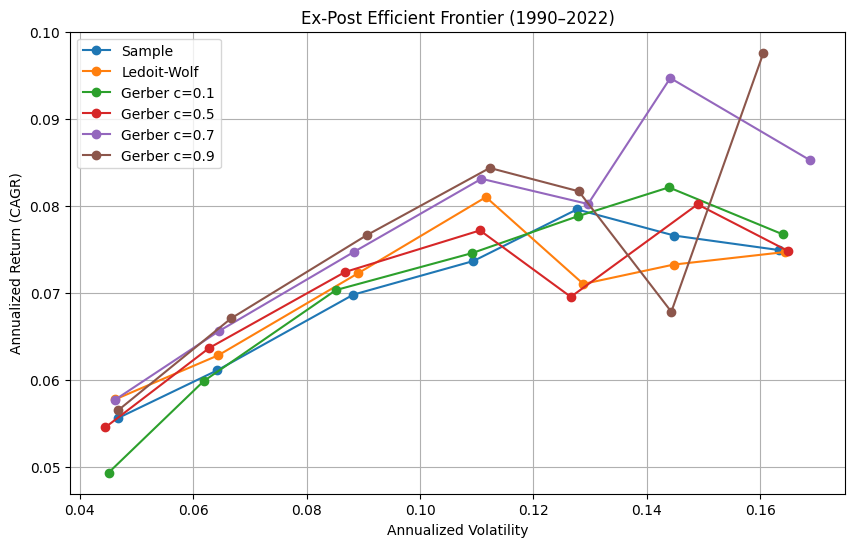

In [20]:
results = {
    "Sample": perf_sample,
    "Ledoit-Wolf": perf_ledoit,
    "Gerber c=0.1": perf_gerber_v4,
    "Gerber c=0.5": perf_gerber_v1,
    "Gerber c=0.7": perf_gerber_v2,
    "Gerber c=0.9": perf_gerber_v3
}

plot_efficient_frontier(results, title="Ex-Post Efficient Frontier (1990–2022)")

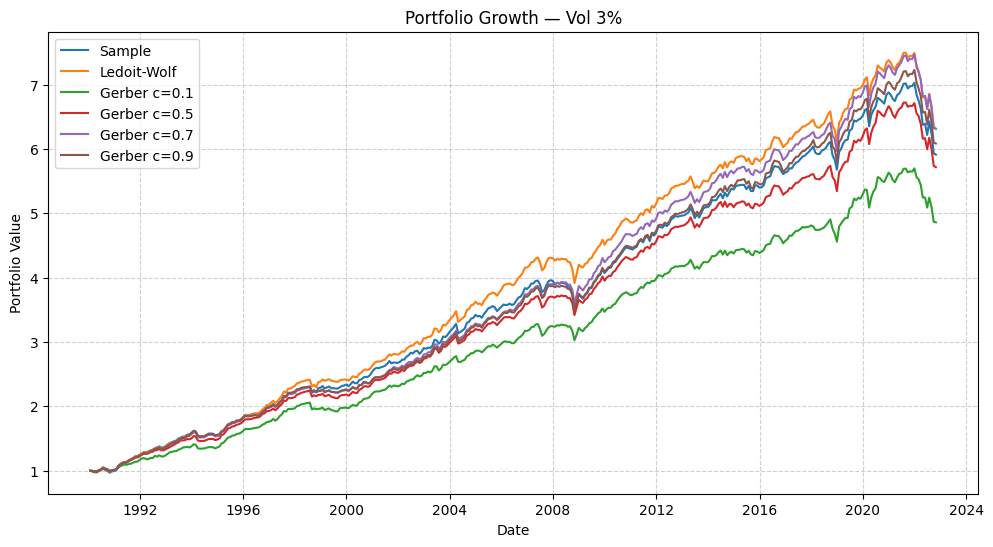

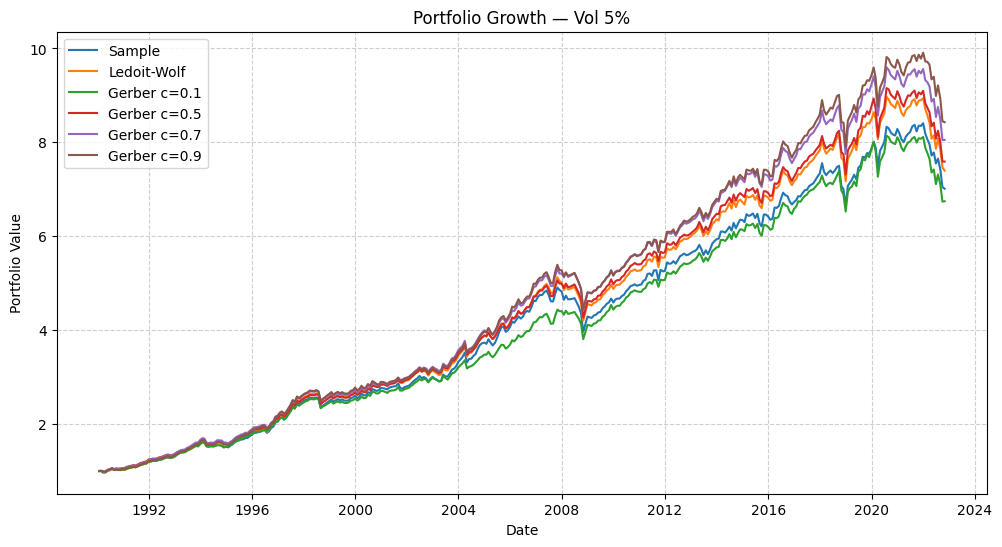

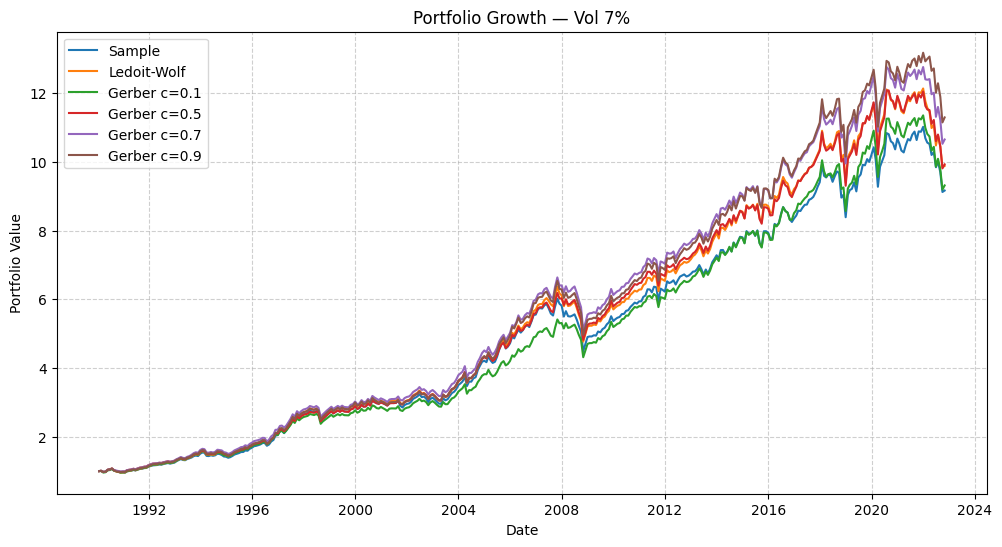

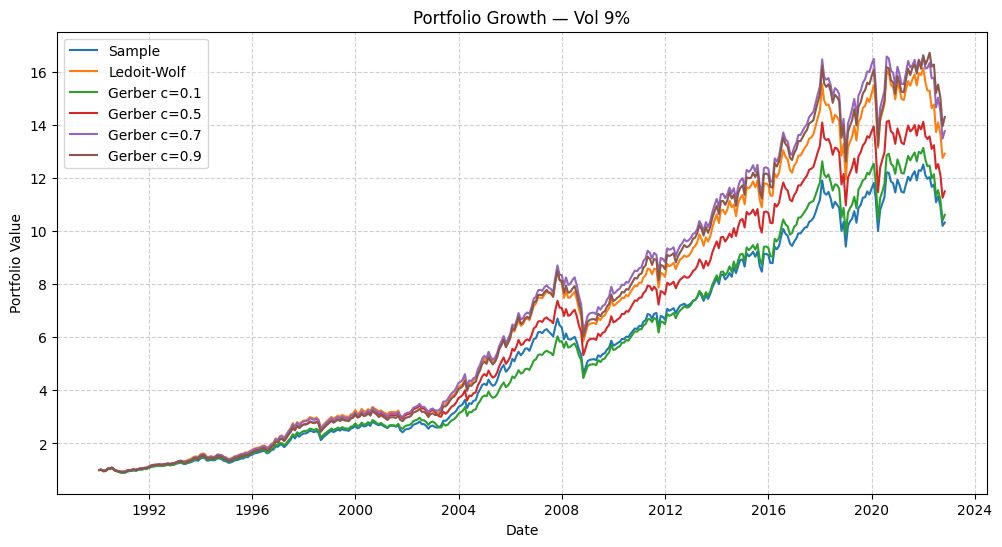

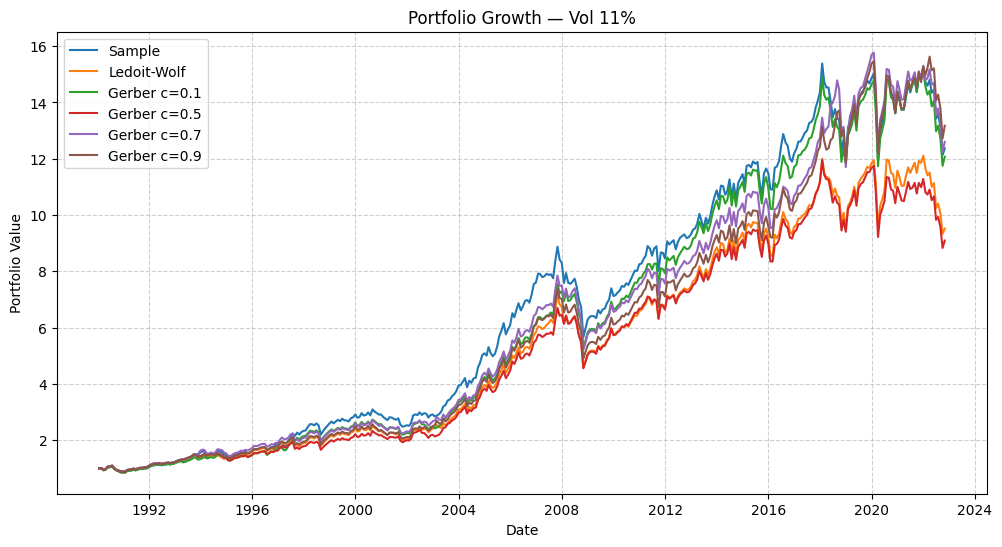

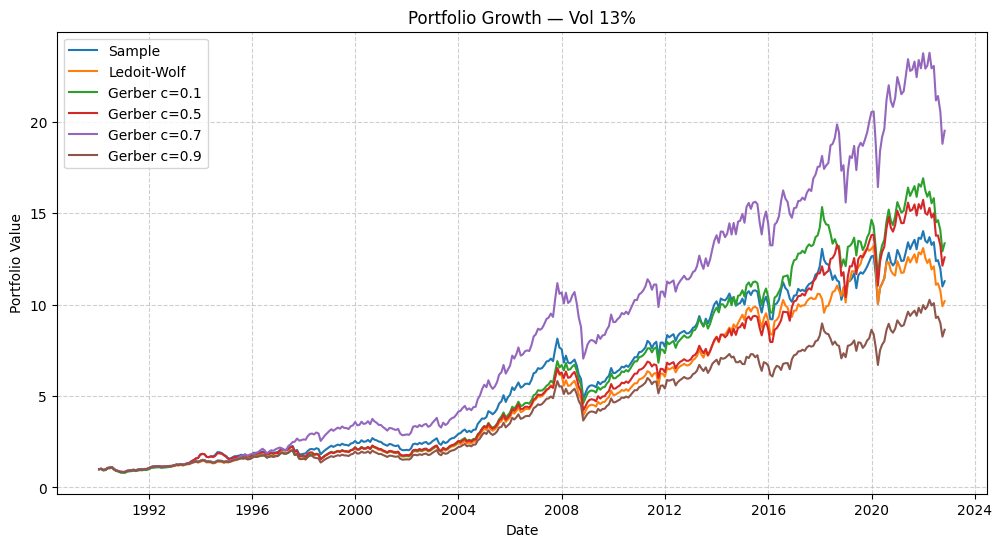

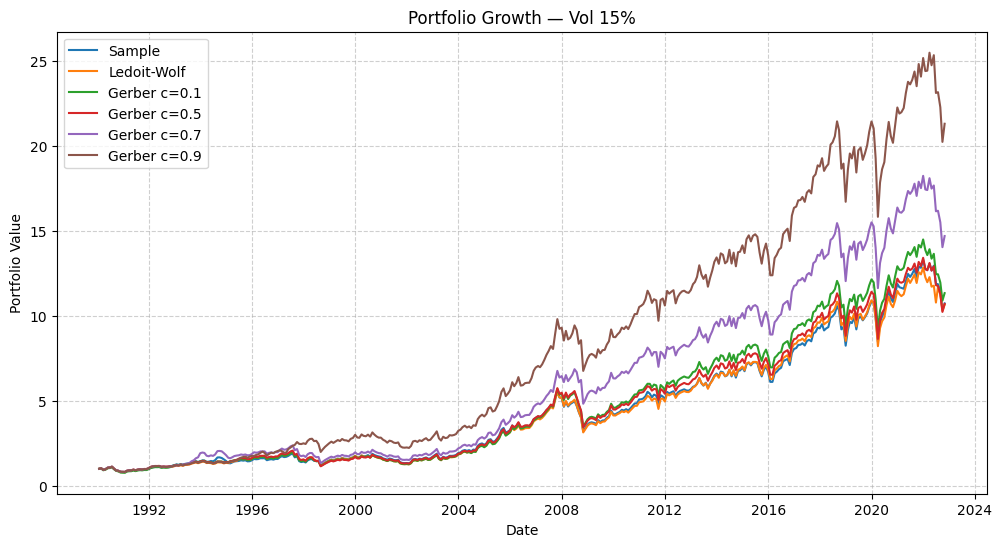

In [21]:
returns_dicts = {
    "Sample": returns_dict_sample,
    "Ledoit-Wolf": returns_dict_ledoit,
    "Gerber c=0.1": returns_dict_gerber_v4,
    "Gerber c=0.5": returns_dict_gerber_v1,
    "Gerber c=0.7": returns_dict_gerber_v2,
    "Gerber c=0.9": returns_dict_gerber_v3
}

plot_all_portfolio_series(returns_dicts, start_value=1.0, title_prefix="Portfolio Growth")


Then we look at the original optimization problem
- i.e. $w_t^\top \hat{\Sigma}_t w_t \le (\sigma^*)^2$

In [22]:
# full sample

target_stds = [v/100 for v in range(3, 16, 2)]

# --- Run rolling optimization with Gerber covariance (cvxpy) ---
weights_dict_gerber_v1 = rolling_mvo(data_gerber,
                                     target_stds=target_stds,
                                     window=24,
                                     cov_type="gerber",
                                     c=0.5,
                                     use_cvxpy=True)

weights_dict_gerber_v2 = rolling_mvo(data_gerber,
                                     target_stds=target_stds,
                                     window=24,
                                     cov_type="gerber",
                                     c=0.7,
                                     use_cvxpy=True)

weights_dict_gerber_v3 = rolling_mvo(data_gerber,
                                     target_stds=target_stds,
                                     window=24,
                                     cov_type="gerber",
                                     c=0.9,
                                     use_cvxpy=True)

weights_dict_gerber_v4 = rolling_mvo(data_gerber,
                                     target_stds=target_stds,
                                     window=24,
                                     cov_type="gerber",
                                     c=0.1,
                                     use_cvxpy=True)

# --- Run with sample covariance (cvxpy) ---
weights_dict_sample = rolling_mvo(data_gerber,
                                  target_stds=target_stds,
                                  window=24,
                                  cov_type="sample",
                                  use_cvxpy=True)

# --- Run with Ledoit-Wolf covariance (cvxpy) ---
weights_dict_ledoit = rolling_mvo(data_gerber,
                                  target_stds=target_stds,
                                  window=24,
                                  cov_type="ledoit",
                                  use_cvxpy=True)

# --- Build realized returns per risk target ---
returns_dict_sample = {k: portfolio_returns(data_gerber, wdf)
                       for k, wdf in weights_dict_sample.items()}

returns_dict_gerber_v1 = {k: portfolio_returns(data_gerber, wdf)
                          for k, wdf in weights_dict_gerber_v1.items()}

returns_dict_gerber_v2 = {k: portfolio_returns(data_gerber, wdf)
                          for k, wdf in weights_dict_gerber_v2.items()}

returns_dict_gerber_v3 = {k: portfolio_returns(data_gerber, wdf)
                          for k, wdf in weights_dict_gerber_v3.items()}

returns_dict_gerber_v4 = {k: portfolio_returns(data_gerber, wdf)
                          for k, wdf in weights_dict_gerber_v4.items()}

returns_dict_ledoit = {k: portfolio_returns(data_gerber, wdf)
                       for k, wdf in weights_dict_ledoit.items()}

# --- Summarize realized performance ---
perf_sample   = realized_performance(returns_dict_sample)
perf_gerber_v1 = realized_performance(returns_dict_gerber_v1)
perf_gerber_v2 = realized_performance(returns_dict_gerber_v2)
perf_gerber_v3 = realized_performance(returns_dict_gerber_v3)
perf_gerber_v4 = realized_performance(returns_dict_gerber_v4)
perf_ledoit    = realized_performance(returns_dict_ledoit)

# --- Print summaries ---
print("=== Sample covariance (cvxpy) ===")
print(perf_sample.round(4))

print("\n=== Ledoit-Wolf shrinkage (cvxpy) ===")
print(perf_ledoit.round(4))

print("\n=== Gerber covariance (c = 0.5, cvxpy) ===")
print(perf_gerber_v1.round(4))

print("\n=== Gerber covariance (c = 0.7, cvxpy) ===")
print(perf_gerber_v2.round(4))

print("\n=== Gerber covariance (c = 0.9, cvxpy) ===")
print(perf_gerber_v3.round(4))

print("\n=== Gerber covariance (c = 0.1, cvxpy) ===")
print(perf_gerber_v4.round(4))


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


=== Sample covariance (cvxpy) ===
         Realized CAGR  Ann. Volatility  Final Cumulative Return  Months
Vol 3%          0.0556           0.0467                   4.9115   394.0
Vol 5%          0.0607           0.0643                   5.9322   394.0
Vol 7%          0.0697           0.0882                   8.1280   394.0
Vol 9%          0.0727           0.1105                   9.0306   394.0
Vol 11%         0.0750           0.1296                   9.7408   394.0
Vol 13%         0.0800           0.1455                  11.4983   394.0
Vol 15%         0.0806           0.1577                  11.7605   394.0

=== Ledoit-Wolf shrinkage (cvxpy) ===
         Realized CAGR  Ann. Volatility  Final Cumulative Return  Months
Vol 3%          0.0577           0.0462                   5.3178   394.0
Vol 5%          0.0628           0.0644                   6.3779   394.0
Vol 7%          0.0719           0.0890                   8.7813   394.0
Vol 9%          0.0754           0.1120            

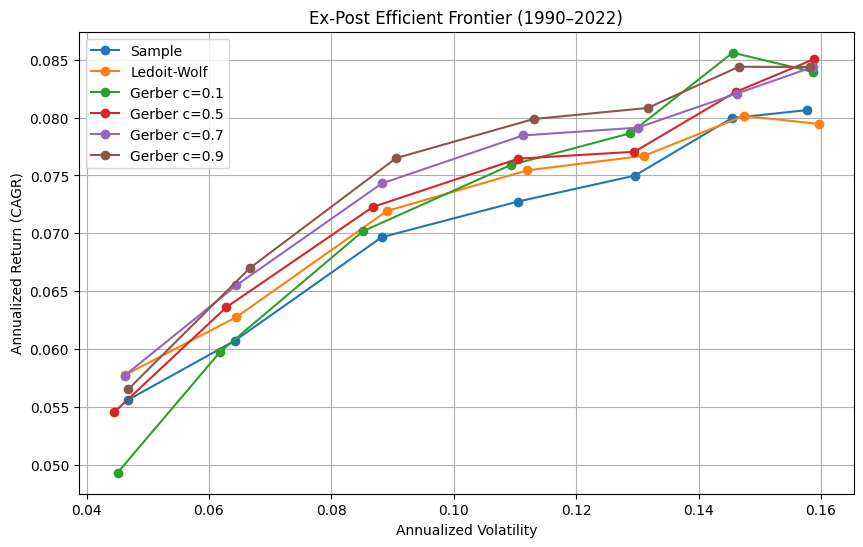

In [23]:
results = {
    "Sample": perf_sample,
    "Ledoit-Wolf": perf_ledoit,
    "Gerber c=0.1": perf_gerber_v4,
    "Gerber c=0.5": perf_gerber_v1,
    "Gerber c=0.7": perf_gerber_v2,
    "Gerber c=0.9": perf_gerber_v3
}

plot_efficient_frontier(results, title="Ex-Post Efficient Frontier (1990–2022)")

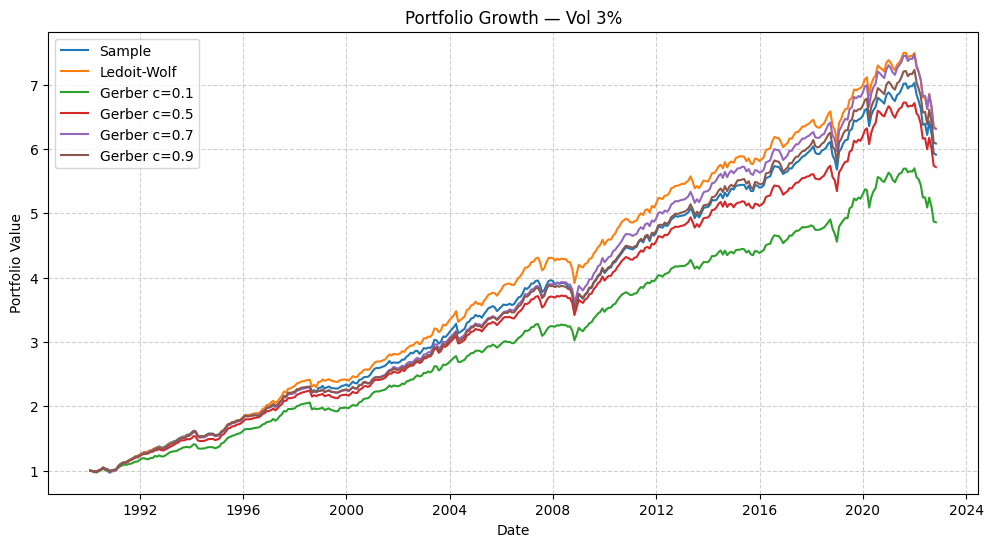

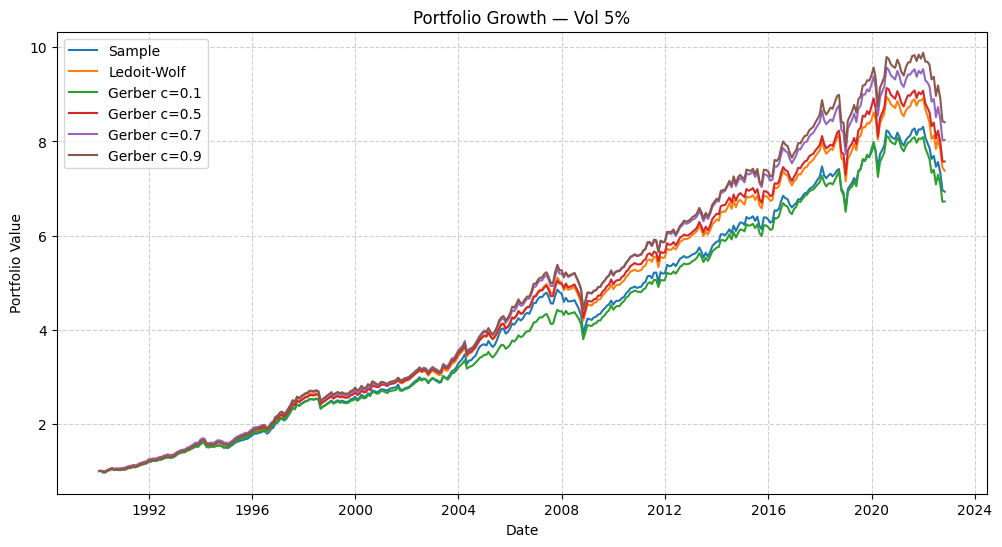

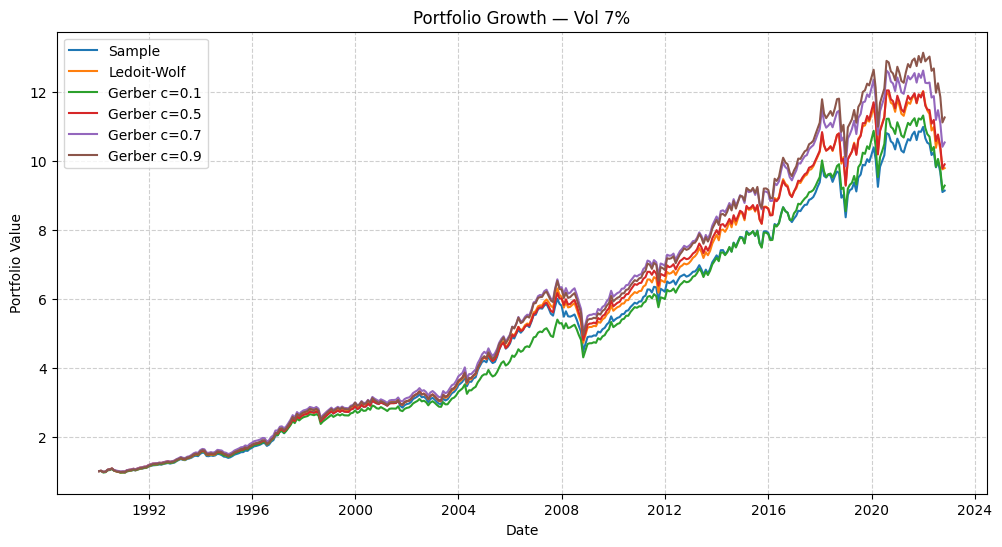

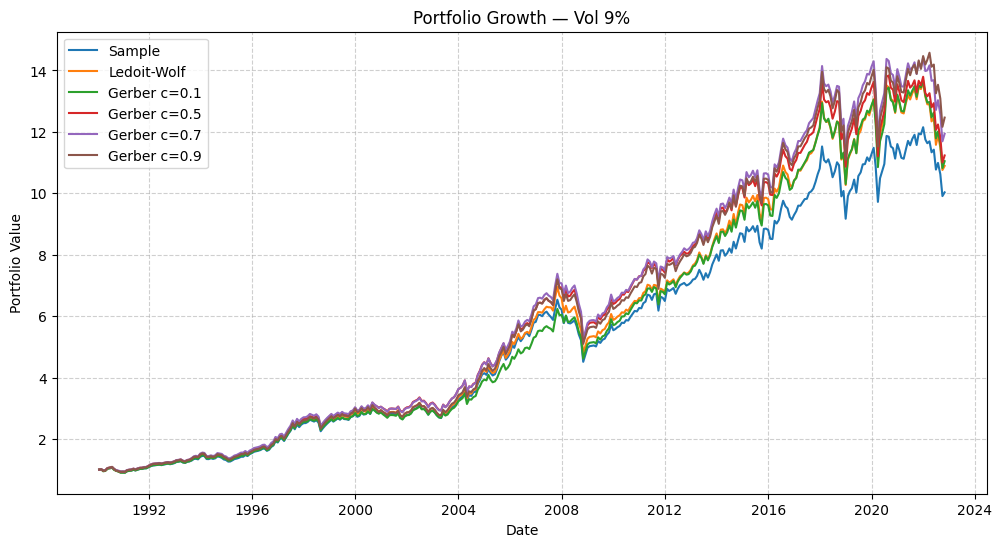

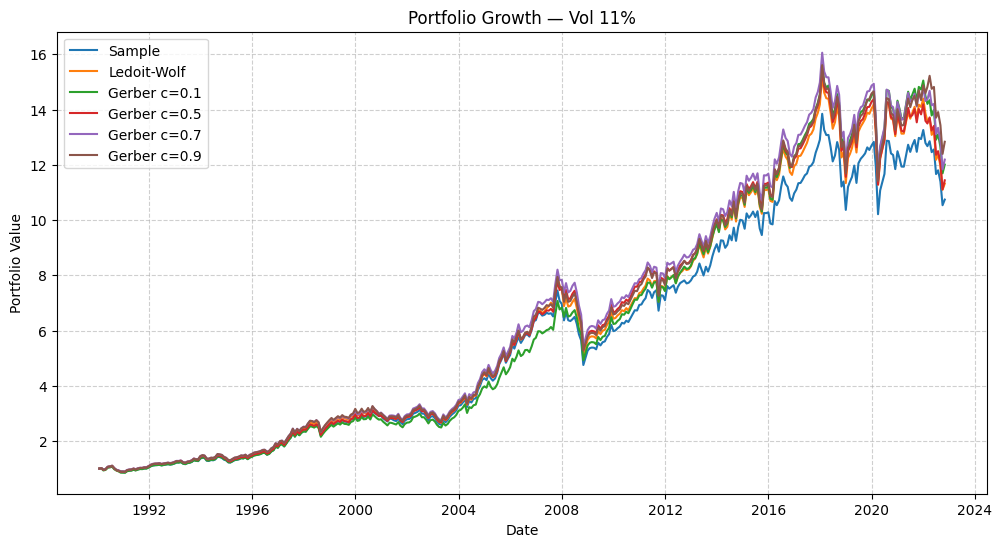

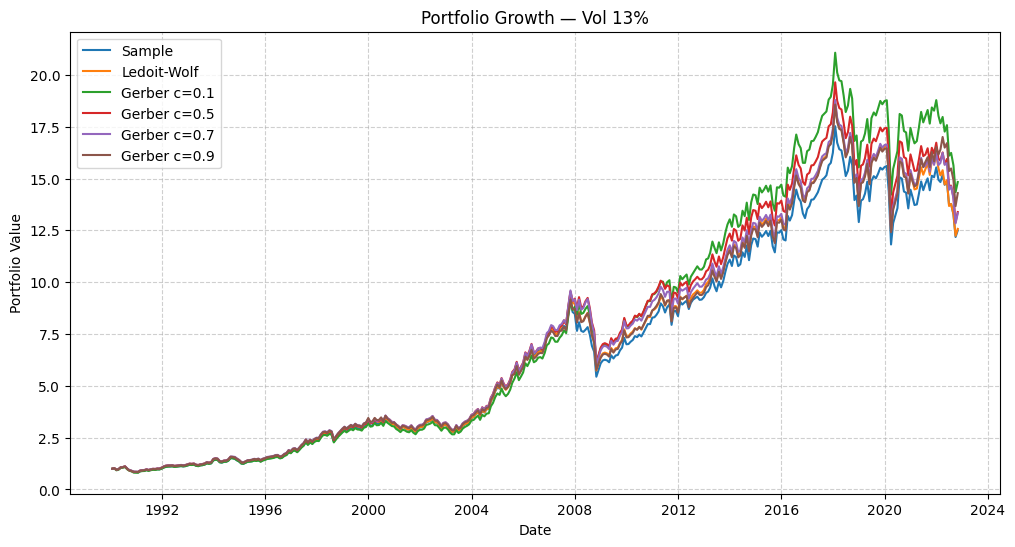

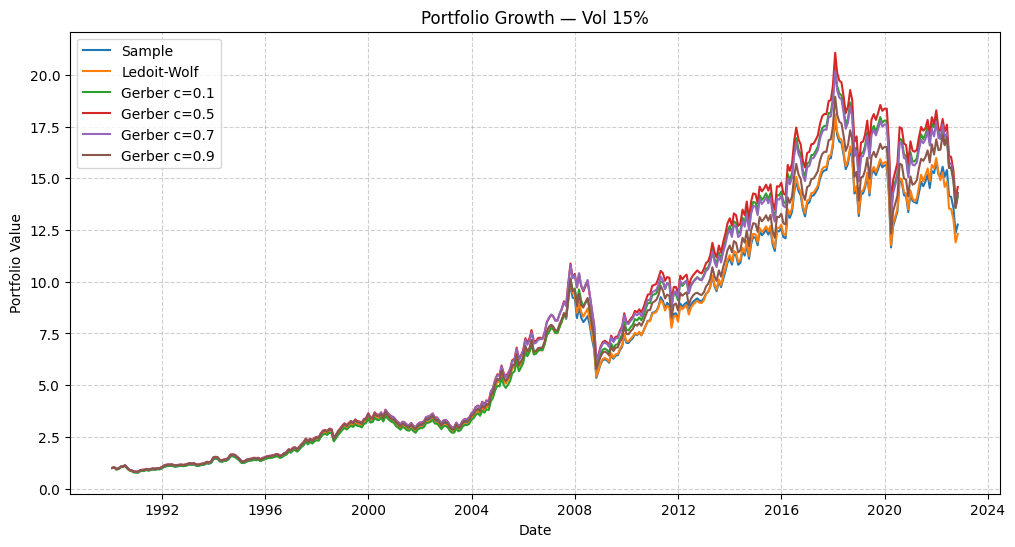

In [24]:
returns_dicts = {
    "Sample": returns_dict_sample,
    "Ledoit-Wolf": returns_dict_ledoit,
    "Gerber c=0.1": returns_dict_gerber_v4,
    "Gerber c=0.5": returns_dict_gerber_v1,
    "Gerber c=0.7": returns_dict_gerber_v2,
    "Gerber c=0.9": returns_dict_gerber_v3
}

plot_all_portfolio_series(returns_dicts, start_value=1.0, title_prefix="Portfolio Growth")

#### My Ideas:
- Non-symmetric thresholds
- Different vol measure for threshold + a return forecast for mu (factor? ML?)
- See how well Gerber capture non-linear dependence
- Compare with equal weighted + a benchmark